## DR funtional visualization

samples have been run through humann3 and identified genefamilies merged into 1 tsv (see  DR_humann_analysis.ipnyb)

In [2]:
#load libraries (not sure I need all these, but just in case)
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

In [2]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR"

In [3]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/humann3/")

In [3]:
genes = read.csv("DR_all_genefamilies_filtered_cpm_named.csv")

In [4]:
head(genes)

,X..Gene.Family,X072023_Carolina_2023_Baya_052_DCYL_S9_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_053_MCAV_S3_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_055_MCAV_S4_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_057_SSID_S7_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_059_SSID_S8_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_061_SSID_S5_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_063_SSID_S6_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_065_DCYL_S1_comb_kraken_filtered_Abundance.CPM,X072023_Carolina_2023_Baya_066_DCYL_S2_comb_kraken_filtered_Abundance.CPM,⋯,X122021_Coralina_2021_Baya_019_SSID1_S46_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_021_SSID2_S36_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_023_MCAV_S31_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_025_MMEA_S22_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_027_PSTR4_S34_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_029_MMEA_S23_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_031_MMEA_S45_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_033_PSTR7_S35_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_035_PSTR_S32_comb_kraken_filtered_Abundance.CPM,X122021_Coralina_2021_Baya_037_PSTR_S33_comb_kraken_filtered_Abundance.CPM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNGROUPED,9.96076e+05,975472,804191.000,959897,959991,841601.0000,7.47849e+05,988831,862835.000,⋯,842685.0000,997213,972242.0000,824356,993072,895201,834589,994528,993365,992524
2,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0.00000e+00,0,0.000,0,0,0.0000,4.87521e+04,0,0.000,⋯,0.0000,0,0.0000,0,0,0,0,0,0,0
3,UNGROUPED|unclassified,9.96076e+05,975472,804191.000,959897,959991,841601.0000,6.99096e+05,988831,862835.000,⋯,842685.0000,997213,972242.0000,824356,993072,895201,834589,994528,993365,992524
4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192e+00,0,146.037,0,0,50.0707,6.55714e+01,0,100.545,⋯,31.5559,0,61.9926,0,0,0,0,0,0,0
5,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|g__Cutibacterium.s__Cutibacterium_acnes,0.00000e+00,0,0.000,0,0,0.0000,6.62675e+00,0,0.000,⋯,0.0000,0,0.0000,0,0,0,0,0,0,0
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|unclassified,1.84192e+00,0,146.037,0,0,50.0707,5.89446e+01,0,100.545,⋯,31.5559,0,61.9926,0,0,0,0,0,0,0


In [5]:
#change headers
names(genes)[1] <- "Gene_Family"
names(genes) <- sub("^X", "", names(genes))
names(genes) <- sub("_comb_kraken_filtered_Abundance.CPM","", names(genes))
head(genes)

,Gene_Family,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNGROUPED,9.96076e+05,975472,804191.000,959897,959991,841601.0000,7.47849e+05,988831,862835.000,⋯,842685.0000,997213,972242.0000,824356,993072,895201,834589,994528,993365,992524
2,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0.00000e+00,0,0.000,0,0,0.0000,4.87521e+04,0,0.000,⋯,0.0000,0,0.0000,0,0,0,0,0,0,0
3,UNGROUPED|unclassified,9.96076e+05,975472,804191.000,959897,959991,841601.0000,6.99096e+05,988831,862835.000,⋯,842685.0000,997213,972242.0000,824356,993072,895201,834589,994528,993365,992524
4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192e+00,0,146.037,0,0,50.0707,6.55714e+01,0,100.545,⋯,31.5559,0,61.9926,0,0,0,0,0,0,0
5,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|g__Cutibacterium.s__Cutibacterium_acnes,0.00000e+00,0,0.000,0,0,0.0000,6.62675e+00,0,0.000,⋯,0.0000,0,0.0000,0,0,0,0,0,0,0
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|unclassified,1.84192e+00,0,146.037,0,0,50.0707,5.89446e+01,0,100.545,⋯,31.5559,0,61.9926,0,0,0,0,0,0,0


In [6]:
#remove specific rows
genes_filtered <- genes[!grepl("UNMAPPED|UNGROUPED", genes$Gene_Family), ]
#genes <- genes[!grepl("UNGROUPED", genes$Gene_Family), ]
head(genes_filtered)

,Gene_Family,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192,0,146.0370,0.0000,0,50.0707,65.57140,0,100.5450,⋯,31.5559,0,61.9926,0,0.00000,0,0,0,0,0
5,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|g__Cutibacterium.s__Cutibacterium_acnes,0.00000,0,0.0000,0.0000,0,0.0000,6.62675,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|unclassified,1.84192,0,146.0370,0.0000,0,50.0707,58.94460,0,100.5450,⋯,31.5559,0,61.9926,0,0.00000,0,0,0,0,0
7,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,12.6499,21.5426,0,11.7578,52.04480,0,33.9994,⋯,28.1884,0,0.0000,0,2.08926,0,0,0,0,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127]|unclassified,0.00000,0,12.6499,21.5426,0,11.7578,52.04480,0,33.9994,⋯,28.1884,0,0.0000,0,2.08926,0,0,0,0,0
9,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0,0.0000,0.0000,0,0.0000,16.22250,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0


In [7]:
#remove the "unclassified" versions 
genes_filtered <- genes_filtered[!grepl("unclassified", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim(genes_filtered)

,Gene_Family,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192,0,146.0370,0.0000,0,50.0707,65.57140,0,100.5450,⋯,31.5559,0,61.9926,0,0.00000,0,0,0,0,0
5,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|g__Cutibacterium.s__Cutibacterium_acnes,0.00000,0,0.0000,0.0000,0,0.0000,6.62675,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0
7,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,12.6499,21.5426,0,11.7578,52.04480,0,33.9994,⋯,28.1884,0,0.0000,0,2.08926,0,0,0,0,0
9,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0,0.0000,0.0000,0,0.0000,16.22250,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0
11,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0,0.0000,0.0000,0,0.0000,5.36775,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0
13,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.00000,0,0.0000,0.0000,0,16.9971,0.00000,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0


[1] 4033   29

In [8]:
#remove rows with "g__Cutibacterium.s__Cutibacterium_acnes"
genes_filtered <- genes_filtered[!grepl("g__Cutibacterium.s__Cutibacterium_acnes", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim (genes_filtered)

,Gene_Family,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192,0,146.0370,0.0000,0,50.0707,65.57140,0,100.5450,⋯,31.5559,0,61.9926,0,0.00000,0,0,0,0,0
7,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,12.6499,21.5426,0,11.7578,52.04480,0,33.9994,⋯,28.1884,0,0.0000,0,2.08926,0,0,0,0,0
9,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0,0.0000,0.0000,0,0.0000,16.22250,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0
11,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0,0.0000,0.0000,0,0.0000,5.36775,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0
13,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.00000,0,0.0000,0.0000,0,16.9971,0.00000,0,0.0000,⋯,0.0000,0,0.0000,0,0.00000,0,0,0,0,0
15,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.00000,0,0.0000,0.0000,0,30.5974,10.66000,0,0.0000,⋯,41.9772,0,0.0000,0,0.00000,0,0,0,0,0


[1] 3315   29

In [14]:
#just checking to see
write.csv(as.data.frame(genes_filtered), file= "DR_all_genes_filtered_ready.csv")

In [9]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
#also included Gene_Family first, to keep that the first column
column_list <- readLines("DR_column_order.txt")
genes_filtered_reordered <- genes_filtered[, column_list]
head(genes_filtered_reordered)

,Gene_Family,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,146.0370,0,0,98.3238,0,61.9926,1.84192,0,⋯,50.0707,65.57140,31.5559,0,0.00000,0,0,0,0.0000,0
7,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,12.6499,0,0,0.0000,0,0.0000,0.00000,0,⋯,11.7578,52.04480,28.1884,0,2.08926,0,0,0,0.0000,0
9,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,0.0000,16.22250,0.0000,0,0.00000,0,0,0,0.0000,0
11,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,0.0000,5.36775,0.0000,0,0.00000,0,0,0,0.0000,0
13,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,16.9971,0.00000,0.0000,0,0.00000,0,0,0,0.0000,0
15,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,30.5974,10.66000,41.9772,0,0.00000,0,0,0,42.8419,0


In [10]:
# make the index the gene_family
row.names(genes_filtered_reordered) <- genes_filtered_reordered$Gene_Family
genes_filtered_reordered$Gene_Family <- NULL
head(genes_filtered_reordered)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,146.0370,0,0,98.3238,0,61.9926,1.84192,0,100.5450,⋯,50.0707,65.57140,31.5559,0,0.00000,0,0,0,0.0000,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,12.6499,0,0,0.0000,0,0.0000,0.00000,0,33.9994,⋯,11.7578,52.04480,28.1884,0,2.08926,0,0,0,0.0000,0
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,16.22250,0.0000,0,0.00000,0,0,0,0.0000,0
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,5.36775,0.0000,0,0.00000,0,0,0,0.0000,0
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,16.9971,0.00000,0.0000,0,0.00000,0,0,0,0.0000,0
1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,30.5974,10.66000,41.9772,0,0.00000,0,0,0,42.8419,0


In [11]:
#transpose - want samples as rows
genes_filtered_reordered_t <- t(genes_filtered_reordered)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],1.1.1.272-RXN: (expasy) D-2-hydroxyacid dehydrogenase (NADP(+)) [1.1.1.272],1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],⋯,URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],UTPHEXPURIDYLYLTRANS-RXN: (expasy) AMBIGUOUS [2.7.7.10; 2.7.7.64],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],VINYLACETYL-COA-DELTA-ISOMERASE-RXN: (expasy) Vinylacetyl-CoA Delta-isomerase [5.3.3.3],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
072023_Carolina_2023_Baya_053_MCAV_S3,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,0.0000,0.000,0.000,0.0000,22.1086,27.9675,0.0000,0
072023_Carolina_2023_Baya_055_MCAV_S4,146.0370,12.6499,0,0,0,0,10.4156,15.0506,0,5.18922,⋯,120.0850,29.8343,135.3440,78.255,19.088,74.4111,210.5870,150.7670,25.6621,0
122021_Coralina_2021_Baya_003_MCAV_S27,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0
122021_Coralina_2021_Baya_005_MCAV_S28,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,79.5434,0.000,0.000,0.0000,68.3230,55.2287,94.6523,0
122021_Coralina_2021_Baya_007_MCAV_S29,98.3238,0.0000,0,0,0,0,0.0000,0.0000,0,24.32400,⋯,68.4683,0.0000,0.0000,0.000,0.000,0.0000,0.0000,88.8660,0.0000,0
122021_Coralina_2021_Baya_017_MCAV_S30,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,68.2940,0.000,0.000,0.0000,0.0000,33.3140,0.0000,0


In [12]:
#convert to matrix
genes_filtered_reordered_t=as.matrix(genes_filtered_reordered_t)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],1.1.1.272-RXN: (expasy) D-2-hydroxyacid dehydrogenase (NADP(+)) [1.1.1.272],1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],⋯,URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],UTPHEXPURIDYLYLTRANS-RXN: (expasy) AMBIGUOUS [2.7.7.10; 2.7.7.64],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],VINYLACETYL-COA-DELTA-ISOMERASE-RXN: (expasy) Vinylacetyl-CoA Delta-isomerase [5.3.3.3],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
072023_Carolina_2023_Baya_053_MCAV_S3,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,0.0000,0.000,0.000,0.0000,22.1086,27.9675,0.0000,0
072023_Carolina_2023_Baya_055_MCAV_S4,146.0370,12.6499,0,0,0,0,10.4156,15.0506,0,5.18922,⋯,120.0850,29.8343,135.3440,78.255,19.088,74.4111,210.5870,150.7670,25.6621,0
122021_Coralina_2021_Baya_003_MCAV_S27,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0
122021_Coralina_2021_Baya_005_MCAV_S28,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,79.5434,0.000,0.000,0.0000,68.3230,55.2287,94.6523,0
122021_Coralina_2021_Baya_007_MCAV_S29,98.3238,0.0000,0,0,0,0,0.0000,0.0000,0,24.32400,⋯,68.4683,0.0000,0.0000,0.000,0.000,0.0000,0.0000,88.8660,0.0000,0
122021_Coralina_2021_Baya_017_MCAV_S30,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0,0.00000,⋯,0.0000,0.0000,68.2940,0.000,0.000,0.0000,0.0000,33.3140,0.0000,0


create distance matrix first
don't do this --> 
set.seed(123)
nmds_ord <- metaMDS(genes_filtered_reordered_t, distance="bray") 

Run 0 stress 0.131112 
Run 1 stress 0.1310217 
... New best solution
... Procrustes: rmse 0.06502269  max resid 0.287471 
Run 2 stress 0.1329143 
Run 3 stress 0.1313091 
... Procrustes: rmse 0.00809964  max resid 0.03138055 
Run 4 stress 0.1311123 
... Procrustes: rmse 0.06503606  max resid 0.2887248 
Run 5 stress 0.1310217 
... Procrustes: rmse 4.002015e-05  max resid 0.0001231674 
... Similar to previous best
Run 6 stress 0.2415202 
Run 7 stress 0.1313091 
... Procrustes: rmse 0.008098021  max resid 0.03137839 
Run 8 stress 0.1467343 
Run 9 stress 0.1476491 
Run 10 stress 0.1311126 
... Procrustes: rmse 0.06504953  max resid 0.2887511 
Run 11 stress 0.132467 
Run 12 stress 0.1548271 
Run 13 stress 0.1289491 
... New best solution
... Procrustes: rmse 0.07476649  max resid 0.348321 
Run 14 stress 0.1792179 
Run 15 stress 0.1329143 
Run 16 stress 0.1546554 
Run 17 stress 0.1317792 
Run 18 stress 0.1289469 
... New best solution
... Procrustes: rmse 0.001080914  max resid 0.003979648 
.

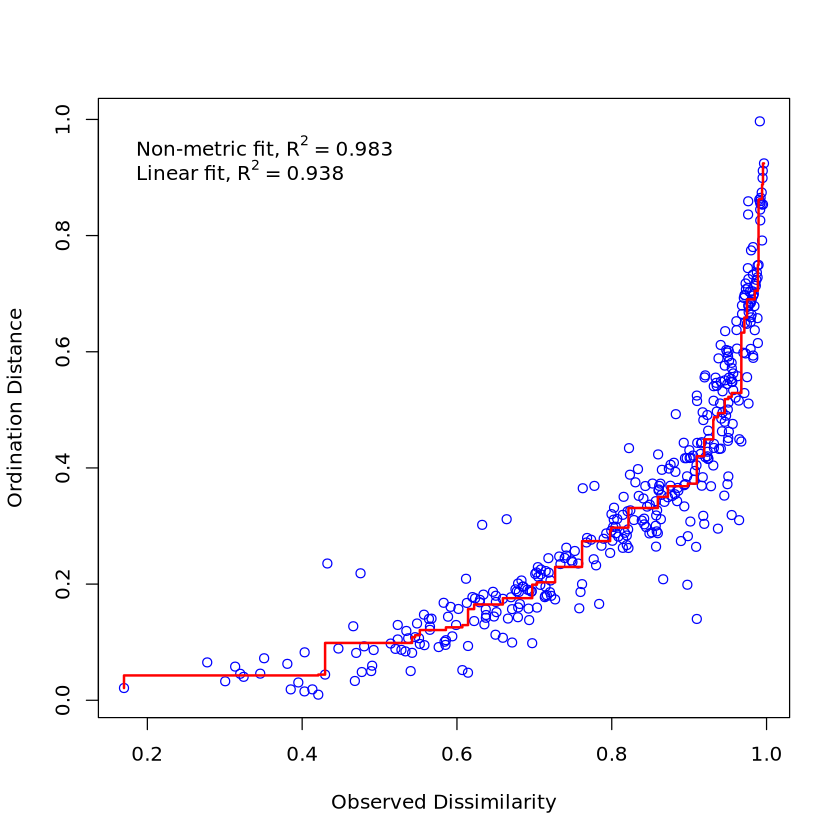

In [20]:
#created the distance matrix (bray curtis) first and then ran metaMDS
bray_dist<- vegdist(genes_filtered_reordered_t, "bray") 
bray<-as.matrix(bray_dist)
write.csv(bray, "bray_distance_matrix.csv")
set.seed(124)
MDS<- metaMDS(bray)
stressplot(MDS)

In [21]:
nmds_scores <- scores(MDS, choices=c(1,2))

In [22]:
write.csv(nmds_scores, file= "nmds_scores_all_genefamilies.csv")

In [23]:
#added a few columns to the scores csv for sample data
plot_scores <- read.csv("DR_nmds_plot_all_genefamilies.csv", header=T)

In [28]:
options(repr.plot.width=10, repr.plot.height=10)

In [4]:
library(RColorBrewer)
library(ggrepel)

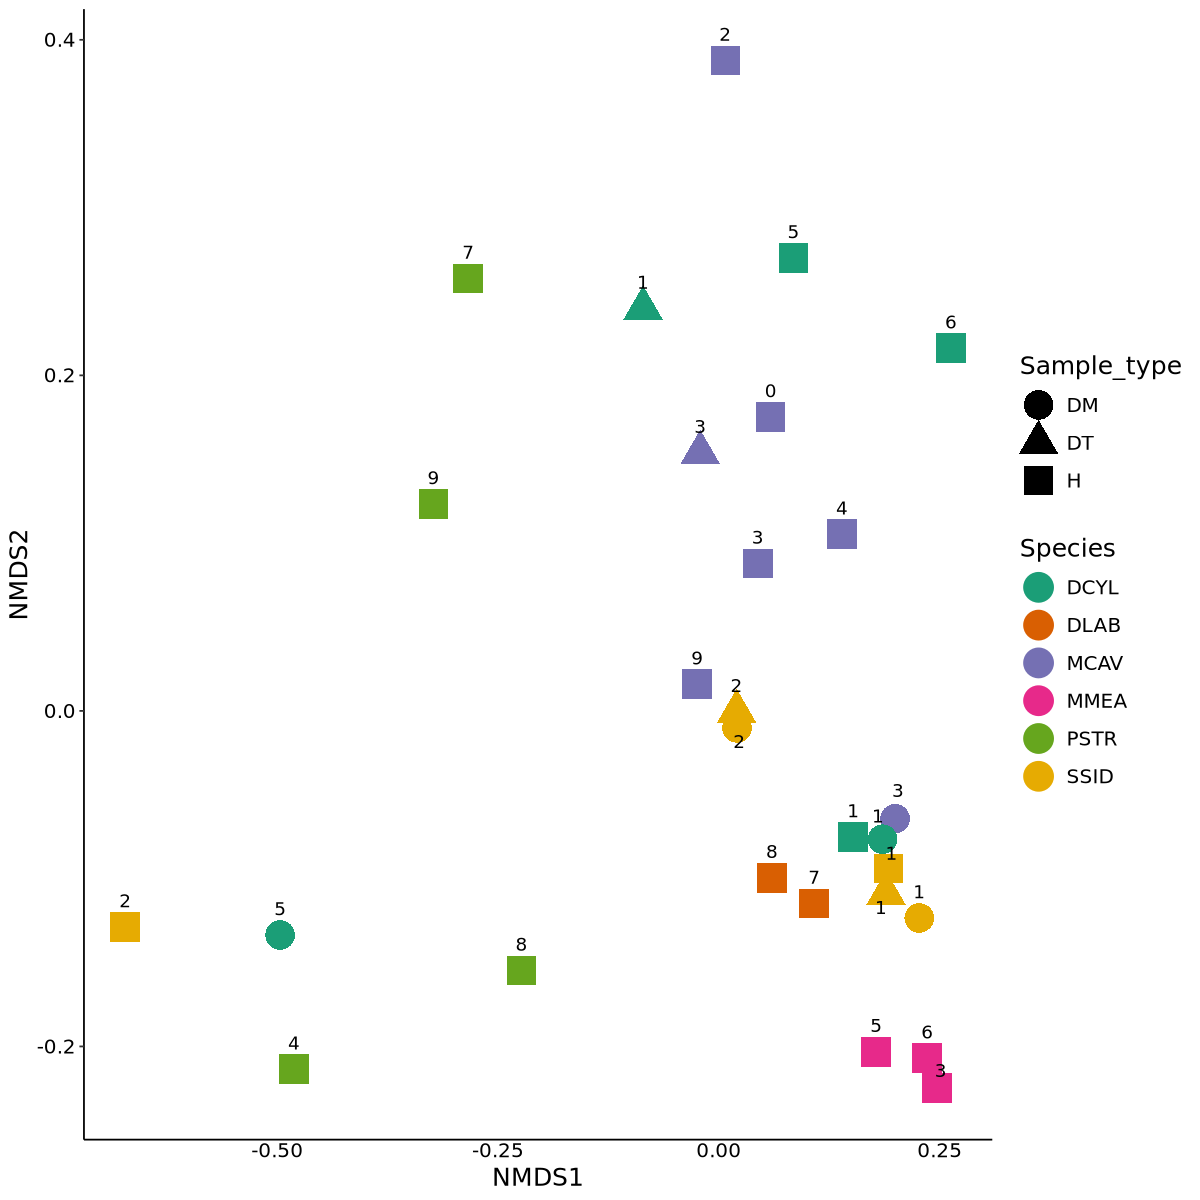

In [29]:
plot <- ggplot(data=plot_scores, aes(x=NMDS1,y=NMDS2, shape= Sample_type, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  #stat_ellipse(level = 0.95, type = "norm") +
  #geom_label(aes(label = Tag), vjust = -1, color = "black") +
  geom_text_repel(aes(label = Tag_num), vjust = -1.5, color = "black", segment.color= "NA") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(), 
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
    
plot

In [30]:
ggsave(filename = "DR_bray_all_genes_nmds.png", plot = plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [5]:
#permanova of distances from gene matrix
#need metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken/DR_metadata_all.csv', header=TRUE)
head(metadata)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
2,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
3,122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
4,122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
5,122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
6,122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [ ]:
# index the SampleIDs (not sure if I need to do this yet)
#row.names(metadata) <- metadata$SampleID
#metadata$SampleID <- NULL
#head(metadata)

In [32]:
permanova <- vegan::adonis2(bray ~ Species*Year, data = metadata, permutations = 999)
print(permanova)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray ~ Species * Year, data = metadata, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)   
Model     8   3.7493 0.41223 1.6657  0.004 **
Residual 19   5.3459 0.58777                 
Total    27   9.0952 1.00000                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [36]:
permanova2 <- vegan::adonis2(bray ~ Species*Sample_type, data = metadata, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray ~ Species * Sample_type, data = metadata, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)   
Model    11   4.5705 0.50252 1.4693  0.007 **
Residual 16   4.5247 0.49748                 
Total    27   9.0952 1.00000                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [34]:
permanova3 <- vegan::adonis2(bray ~ Species, data = metadata, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray ~ Species, data = metadata, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)    
Model     5   2.9757 0.32718 2.1396  0.001 ***
Residual 22   6.1194 0.67282                  
Total    27   9.0952 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### Heatmap of genes/pathways

In [4]:
#install.packages("pheatmap")

In [76]:
#if (!require("remotes")){
#    install.packages("remotes")
#}
#remotes::install_github("gesistsa/rio")

In [77]:
#if (!require("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")

#BiocManager::install("apeglm")

In [78]:
#install.packages("ggpicrust2")

In [13]:
library(tidyverse)
library(magrittr)
library(pheatmap)
library(RColorBrewer)
#library(rio)
library(DESeq2)
library(ggplot2)
library(apeglm)
library(ggpicrust2)
library(ggh4x)
library(dplyr)
library(tidyr)
library(tibble)

In [2]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR"

In [3]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/humann3")

In [41]:
head(genes_filtered_reordered) #then remove the gene_family column, use the one that's not indexed

,Gene_Family,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,146.0370,0,0,98.3238,0,61.9926,1.84192,0,⋯,50.0707,65.57140,31.5559,0,0.00000,0,0,0,0.0000,0
7,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,12.6499,0,0,0.0000,0,0.0000,0.00000,0,⋯,11.7578,52.04480,28.1884,0,2.08926,0,0,0,0.0000,0
9,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,0.0000,16.22250,0.0000,0,0.00000,0,0,0,0.0000,0
11,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,0.0000,5.36775,0.0000,0,0.00000,0,0,0,0.0000,0
13,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,16.9971,0.00000,0.0000,0,0.00000,0,0,0,0.0000,0
15,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,⋯,30.5974,10.66000,41.9772,0,0.00000,0,0,0,42.8419,0


In [42]:
#remove the Gene_family column
genes_filtered_reordered_counts <- genes_filtered_reordered[, -1]
head(genes_filtered_reordered_counts)
dim(genes_filtered_reordered_counts)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,0,146.0370,0,0,98.3238,0,61.9926,1.84192,0,100.5450,⋯,50.0707,65.57140,31.5559,0,0.00000,0,0,0,0.0000,0
7,0,12.6499,0,0,0.0000,0,0.0000,0.00000,0,33.9994,⋯,11.7578,52.04480,28.1884,0,2.08926,0,0,0,0.0000,0
9,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,16.22250,0.0000,0,0.00000,0,0,0,0.0000,0
11,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,5.36775,0.0000,0,0.00000,0,0,0,0.0000,0
13,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,16.9971,0.00000,0.0000,0,0.00000,0,0,0,0.0000,0
15,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,30.5974,10.66000,41.9772,0,0.00000,0,0,0,42.8419,0


[1] 3315   28

In [43]:
genes_filtered_reordered_counts=as.matrix(genes_filtered_reordered_counts)
head(genes_filtered_reordered_counts)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
4,0,146.0370,0,0,98.3238,0,61.9926,1.84192,0,100.5450,⋯,50.0707,65.57140,31.5559,0,0.00000,0,0,0,0.0000,0
7,0,12.6499,0,0,0.0000,0,0.0000,0.00000,0,33.9994,⋯,11.7578,52.04480,28.1884,0,2.08926,0,0,0,0.0000,0
9,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,16.22250,0.0000,0,0.00000,0,0,0,0.0000,0
11,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,5.36775,0.0000,0,0.00000,0,0,0,0.0000,0
13,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,16.9971,0.00000,0.0000,0,0.00000,0,0,0,0.0000,0
15,0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,30.5974,10.66000,41.9772,0,0.00000,0,0,0,42.8419,0


In [46]:
options(repr.plot.width=15, repr.plot.height=15)

Using column 'SampleID' as sample identifier

The Sample Names in order from left to right are:

072023_Carolina_2023_Baya_052_DCYL_S9, 072023_Carolina_2023_Baya_065_DCYL_S1, 072023_Carolina_2023_Baya_066_DCYL_S2, 122021_Coralina_2021_Baya_001_DCYL_S24, 122021_Coralina_2021_Baya_009_DCYL_S25, 122021_Coralina_2021_Baya_010_DCYL_S26, 122021_Coralina_2021_Baya_013_DLAB_S43, 122021_Coralina_2021_Baya_015_DLAB_S44, 072023_Carolina_2023_Baya_053_MCAV_S3, 072023_Carolina_2023_Baya_055_MCAV_S4, 122021_Coralina_2021_Baya_003_MCAV_S27, 122021_Coralina_2021_Baya_005_MCAV_S28, 122021_Coralina_2021_Baya_007_MCAV_S29, 122021_Coralina_2021_Baya_017_MCAV_S30, 122021_Coralina_2021_Baya_023_MCAV_S31, 122021_Coralina_2021_Baya_025_MMEA_S22, 122021_Coralina_2021_Baya_029_MMEA_S23, 122021_Coralina_2021_Baya_031_MMEA_S45, 122021_Coralina_2021_Baya_027_PSTR4_S34, 122021_Coralina_2021_Baya_033_PSTR7_S35, 122021_Coralina_2021_Baya_035_PSTR_S32, 122021_Coralina_2021_Baya_037_PSTR_S33, 072023_Carolina_2023_Baya_

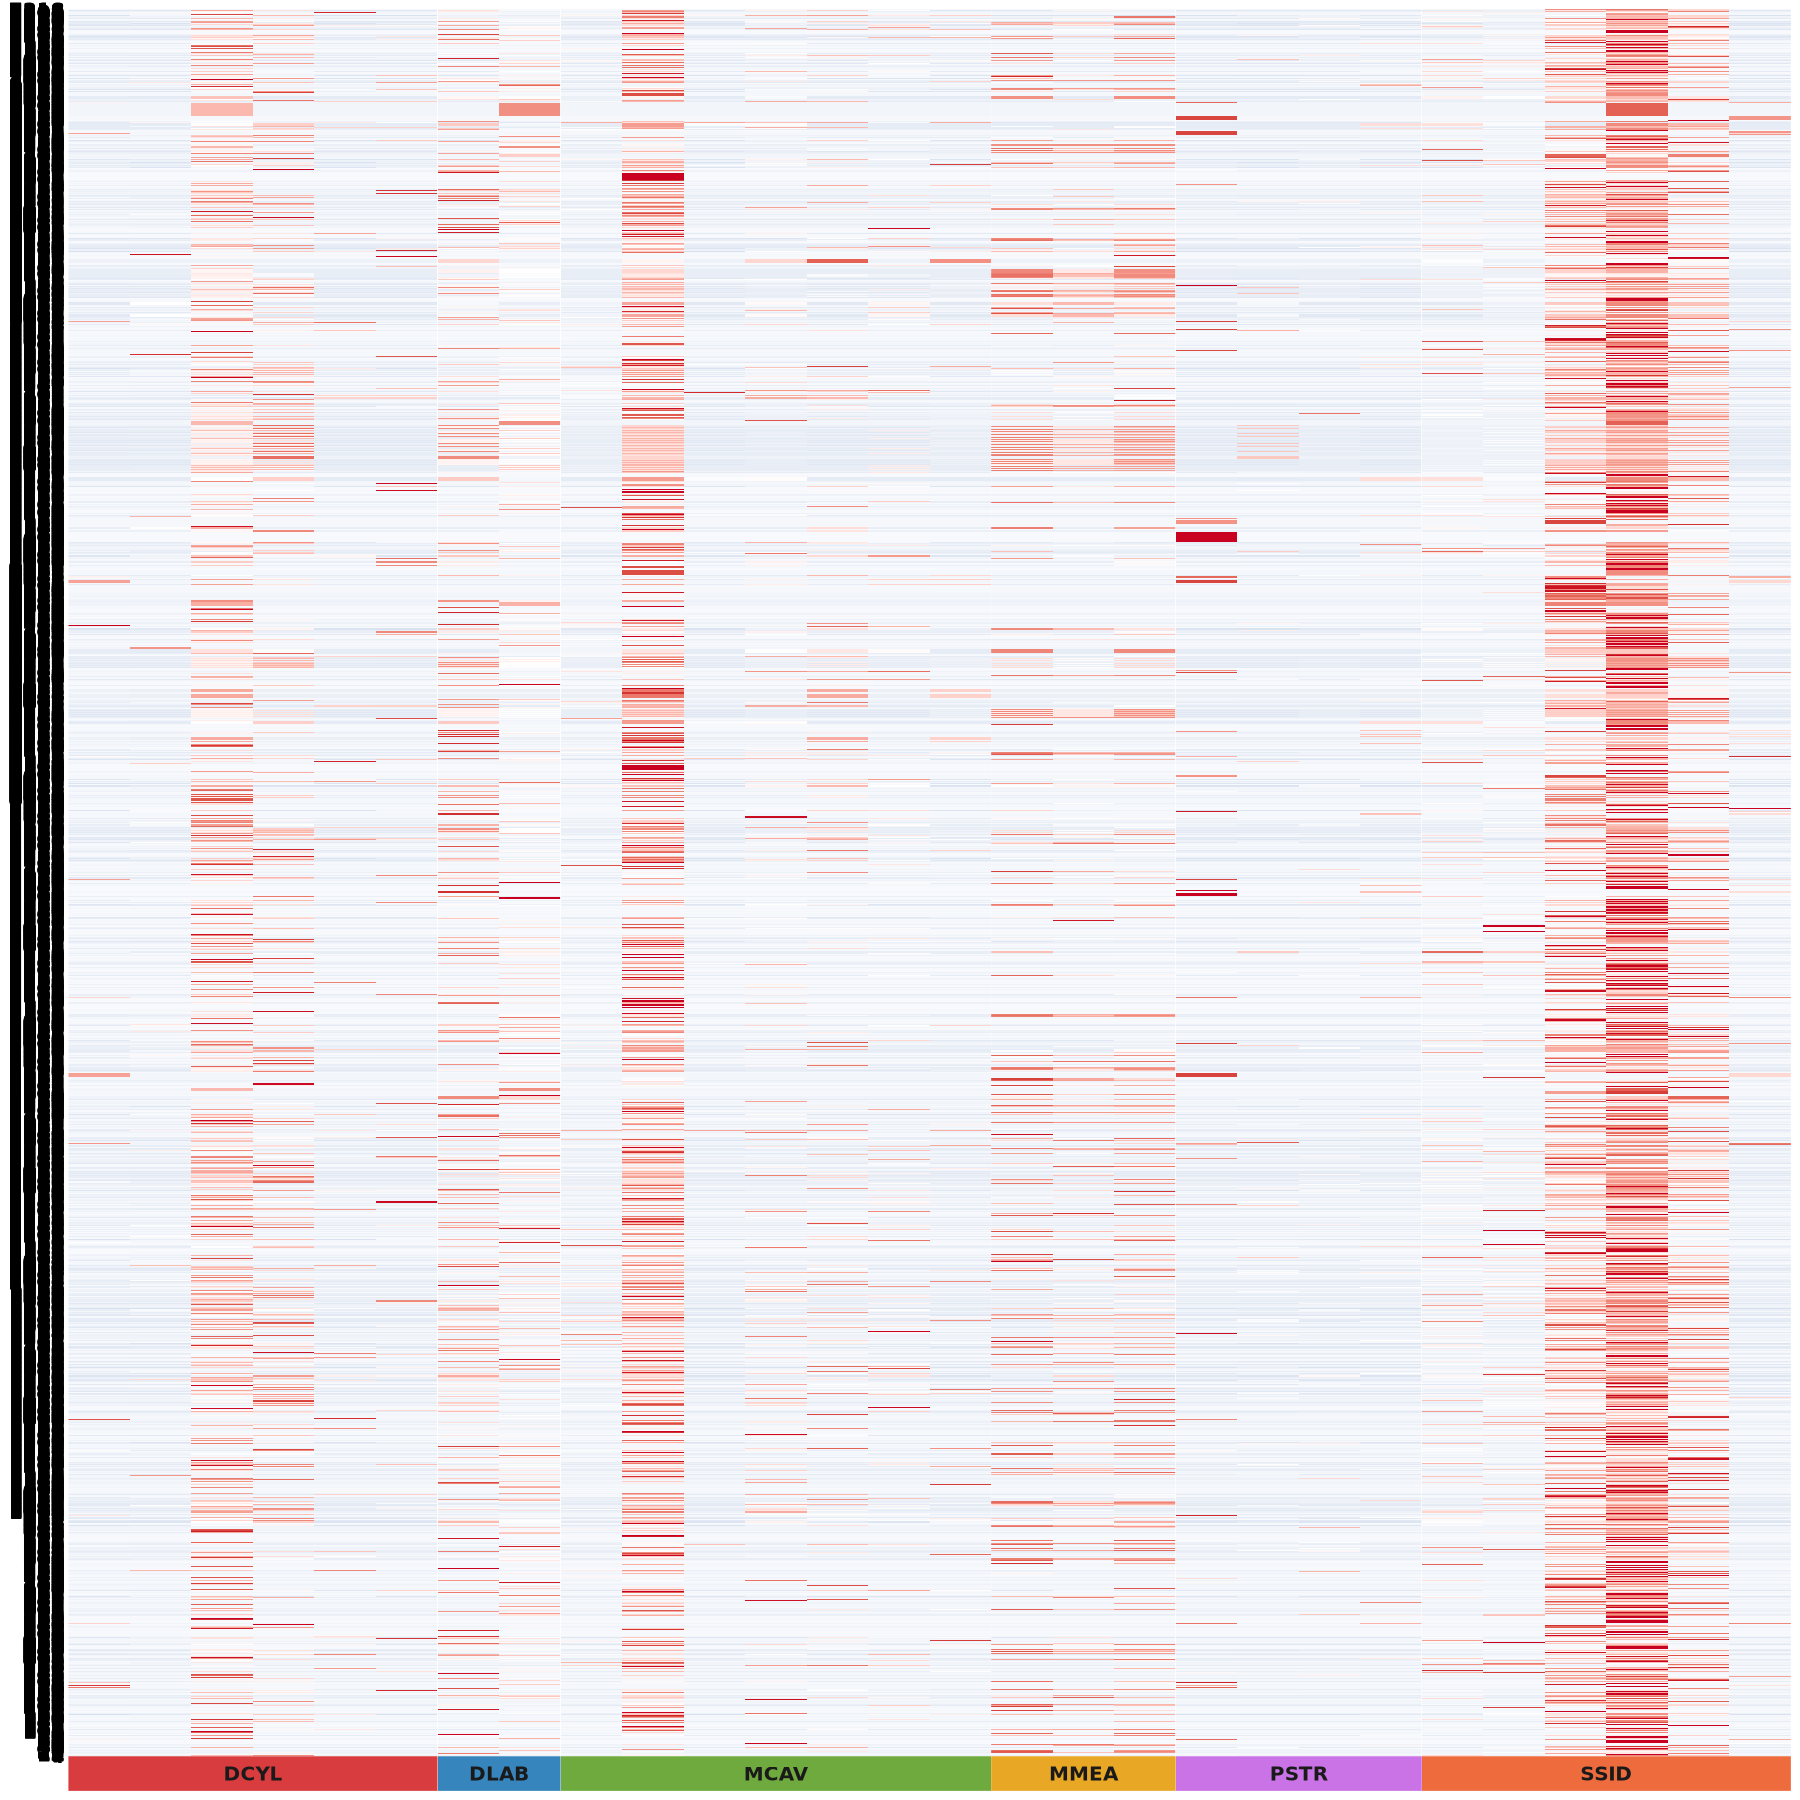

In [47]:
plot1 <- pathway_heatmap(genes_filtered_reordered_counts, metadata, "Species")
plot1

In [145]:
#log normalize
genes_filtered_reordered_log_counts <- log2(genes_filtered_reordered_counts + 1)

In [146]:
#calculate z-score 
mat_z <- t(scale(t(genes_filtered_reordered_log_counts)))

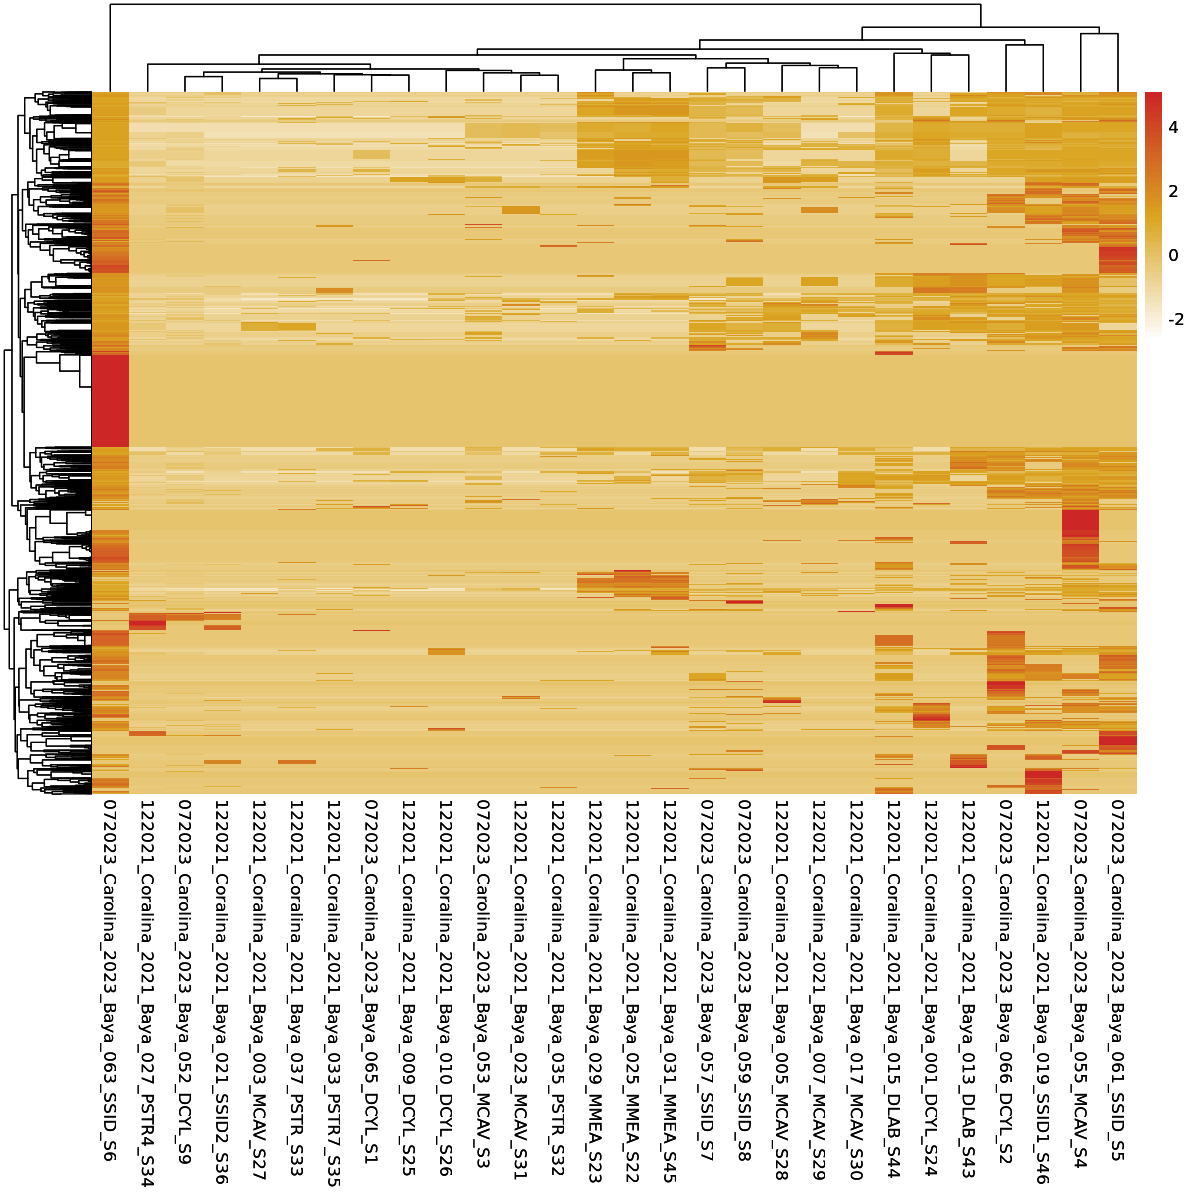

In [148]:
all_genes_plot <- pheatmap(mat_z, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))
all_genes_plot

### Include all samples but using a different approach

The scaling looks more for the extremes of gene abundances, so it doesn't emphasize the similarities as well. Going to log normalize and then make a heatmap that just looks more at relative abundances and see if any patterns pop out better.

In [15]:
head(genes_filtered_reordered)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,146.0370,0,0,98.3238,0,61.9926,1.84192,0,100.5450,⋯,50.0707,65.57140,31.5559,0,0.00000,0,0,0,0.0000,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,12.6499,0,0,0.0000,0,0.0000,0.00000,0,33.9994,⋯,11.7578,52.04480,28.1884,0,2.08926,0,0,0,0.0000,0
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,16.22250,0.0000,0,0.00000,0,0,0,0.0000,0
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,0.0000,5.36775,0.0000,0,0.00000,0,0,0,0.0000,0
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,16.9971,0.00000,0.0000,0,0.00000,0,0,0,0.0000,0
1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0,0.0000,0,0,0.0000,0,0.0000,0.00000,0,0.0000,⋯,30.5974,10.66000,41.9772,0,0.00000,0,0,0,42.8419,0


In [16]:
#make into matrix
genes_filtered_all_l1=as.matrix(genes_filtered_reordered)

In [28]:
#remove rows with zero sum
genes_filtered_all_l1_counts <- genes_filtered_all_l1[rowSums(genes_filtered_all_l1) != 0, ]
dim(genes_filtered_all_l1_counts)

[1] 3315   28

In [29]:
all_log_counts <- log2(genes_filtered_all_l1_counts + 1)

In [10]:
colors <- colorRampPalette(brewer.pal(n = 6, name = "YlGnBu"))(50)

In [22]:
options(repr.plot.width=10, repr.plot.height=10)

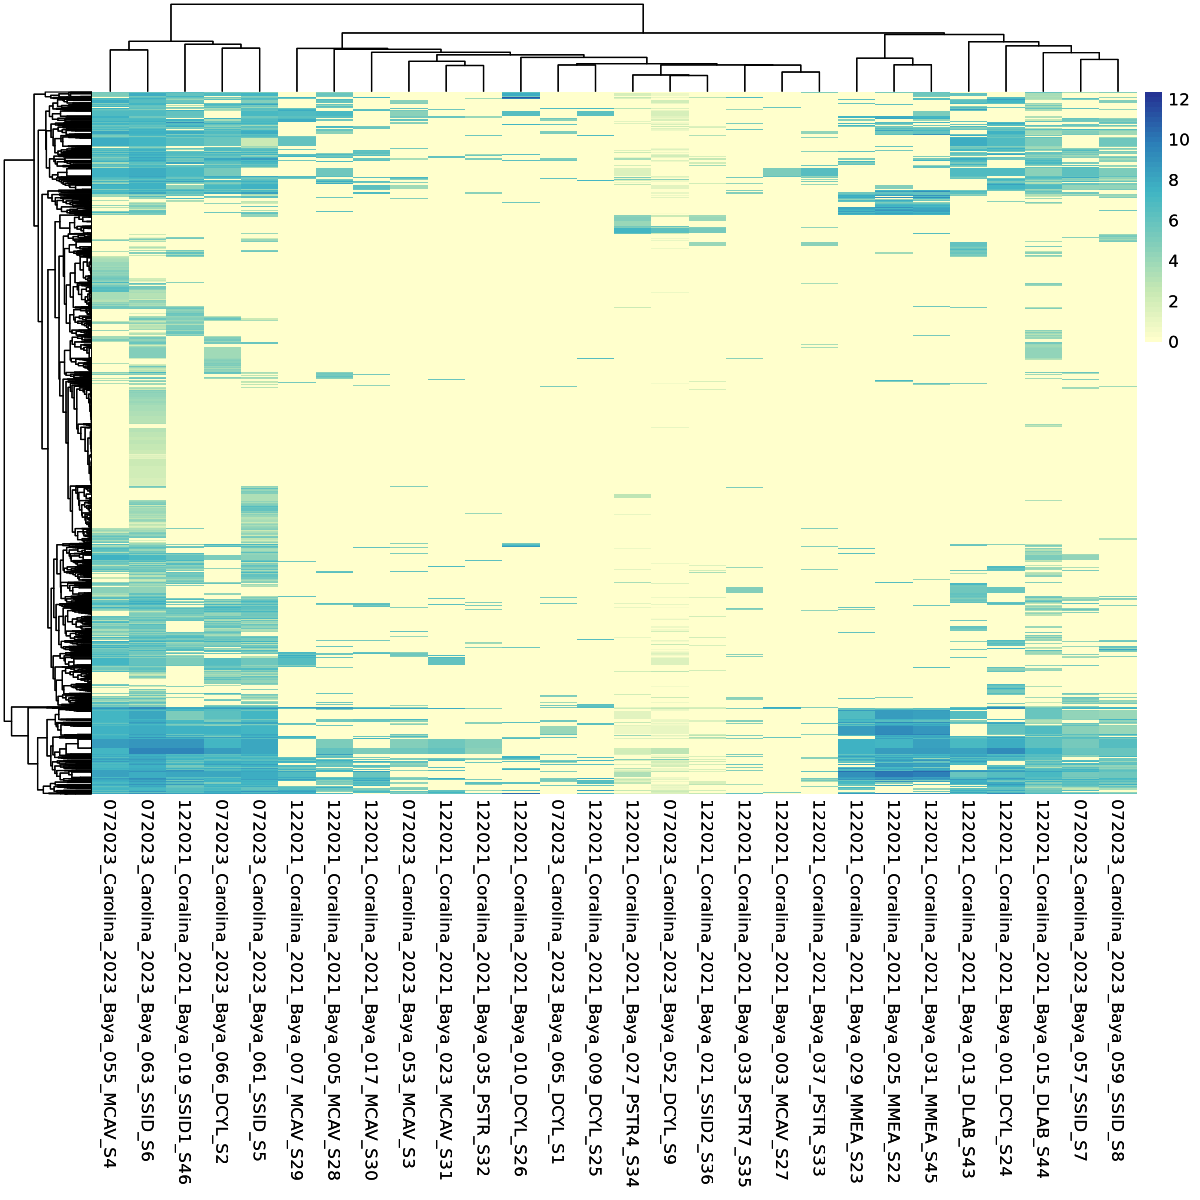

In [30]:
all_genes_log_plot <- pheatmap(all_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         fontsize_col = 10,
         #legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         #legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
all_genes_log_plot

#### remove MMEA, DLAB, and PSTR to just keep the species where we have H, DT, and DM samples


In [52]:
head(metadata)
dim(metadata)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
2,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
3,122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
4,122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
5,122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
6,122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


[1] 28  6

In [55]:
#remove specific rows in metadata
metadata_MCAV_SSID_DCYL <- metadata[!grepl("PSTR|DLAB|MMEA", metadata$SampleID), ]
dim(metadata_MCAV_SSID_DCYL)

[1] 19  6

In [39]:
genes_filtered_MCAV_SSID_DCYL <- read.csv("DR_all_genes_filtered_MCAV_SSID_DCYL.csv")
head(genes_filtered_MCAV_SSID_DCYL)

,X,Gene_Family,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X072023_Carolina_2023_Baya_065_DCYL_S1,⋯,X122021_Coralina_2021_Baya_001_DCYL_S24,X122021_Coralina_2021_Baya_003_MCAV_S27,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_009_DCYL_S25,X122021_Coralina_2021_Baya_010_DCYL_S26,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_019_SSID1_S46,X122021_Coralina_2021_Baya_021_SSID2_S36,X122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192,0,146.0370,0.0000,0,50.0707,65.57140,0,⋯,0.0000,0,0,98.3238,0,0,0,31.5559,0,61.9926
2,7,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,12.6499,21.5426,0,11.7578,52.04480,0,⋯,51.8936,0,0,0.0000,0,0,0,28.1884,0,0.0000
3,9,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0,0.0000,0.0000,0,0.0000,16.22250,0,⋯,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
4,11,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0,0.0000,0.0000,0,0.0000,5.36775,0,⋯,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
5,13,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.00000,0,0.0000,0.0000,0,16.9971,0.00000,0,⋯,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
6,15,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.00000,0,0.0000,0.0000,0,30.5974,10.66000,0,⋯,0.0000,0,0,0.0000,0,0,0,41.9772,0,0.0000


In [42]:
#remove the first column and Xs in headers
genes_filtered_MCAV_SSID_DCYL_counts <- genes_filtered_MCAV_SSID_DCYL[, -1]
names(genes_filtered_MCAV_SSID_DCYL_counts) <- sub("^X", "", names(genes_filtered_MCAV_SSID_DCYL_counts))
head(genes_filtered_MCAV_SSID_DCYL_counts)

,Gene_Family,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_009_DCYL_S25,122021_Coralina_2021_Baya_010_DCYL_S26,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192,0,146.0370,0.0000,0,50.0707,65.57140,0,100.5450,0.0000,0,0,98.3238,0,0,0,31.5559,0,61.9926
2,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,12.6499,21.5426,0,11.7578,52.04480,0,33.9994,51.8936,0,0,0.0000,0,0,0,28.1884,0,0.0000
3,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0,0.0000,0.0000,0,0.0000,16.22250,0,0.0000,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
4,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0,0.0000,0.0000,0,0.0000,5.36775,0,0.0000,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
5,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.00000,0,0.0000,0.0000,0,16.9971,0.00000,0,0.0000,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
6,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.00000,0,0.0000,0.0000,0,30.5974,10.66000,0,0.0000,0.0000,0,0,0.0000,0,0,0,41.9772,0,0.0000


In [43]:
#index Gene_Family
row.names(genes_filtered_MCAV_SSID_DCYL_counts) <- genes_filtered_MCAV_SSID_DCYL_counts$Gene_Family
genes_filtered_MCAV_SSID_DCYL_counts$Gene_Family <- NULL
head(genes_filtered_MCAV_SSID_DCYL_counts)
dim(genes_filtered_MCAV_SSID_DCYL_counts)

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_009_DCYL_S25,122021_Coralina_2021_Baya_010_DCYL_S26,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192,0,146.0370,0.0000,0,50.0707,65.57140,0,100.5450,0.0000,0,0,98.3238,0,0,0,31.5559,0,61.9926
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,12.6499,21.5426,0,11.7578,52.04480,0,33.9994,51.8936,0,0,0.0000,0,0,0,28.1884,0,0.0000
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0,0.0000,0.0000,0,0.0000,16.22250,0,0.0000,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0,0.0000,0.0000,0,0.0000,5.36775,0,0.0000,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.00000,0,0.0000,0.0000,0,16.9971,0.00000,0,0.0000,0.0000,0,0,0.0000,0,0,0,0.0000,0,0.0000
1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.00000,0,0.0000,0.0000,0,30.5974,10.66000,0,0.0000,0.0000,0,0,0.0000,0,0,0,41.9772,0,0.0000


[1] 3315   19

In [44]:
#remove rows with zero sum
genes_filtered_MCAV_SSID_DCYL_counts <- genes_filtered_MCAV_SSID_DCYL_counts[rowSums(genes_filtered_MCAV_SSID_DCYL_counts) != 0, ]
dim(genes_filtered_MCAV_SSID_DCYL_counts)

[1] 3263   19

In [45]:
#make into matrix
genes_filtered_MCAV_SSID_DCYL_counts=as.matrix(genes_filtered_MCAV_SSID_DCYL_counts)

In [46]:
MCAV_SSID_DCYL_log_counts <- log2(genes_filtered_MCAV_SSID_DCYL_counts + 1)

In [33]:
#calculate z-score 
#mat_z_mcav_ssid_dcyl <- t(scale(t(MCAV_SSID_DCYL_log_counts)))

In [34]:
#my_colors <- colorRampPalette(brewer.pal(n = 6, name = "PiYG"))(50)

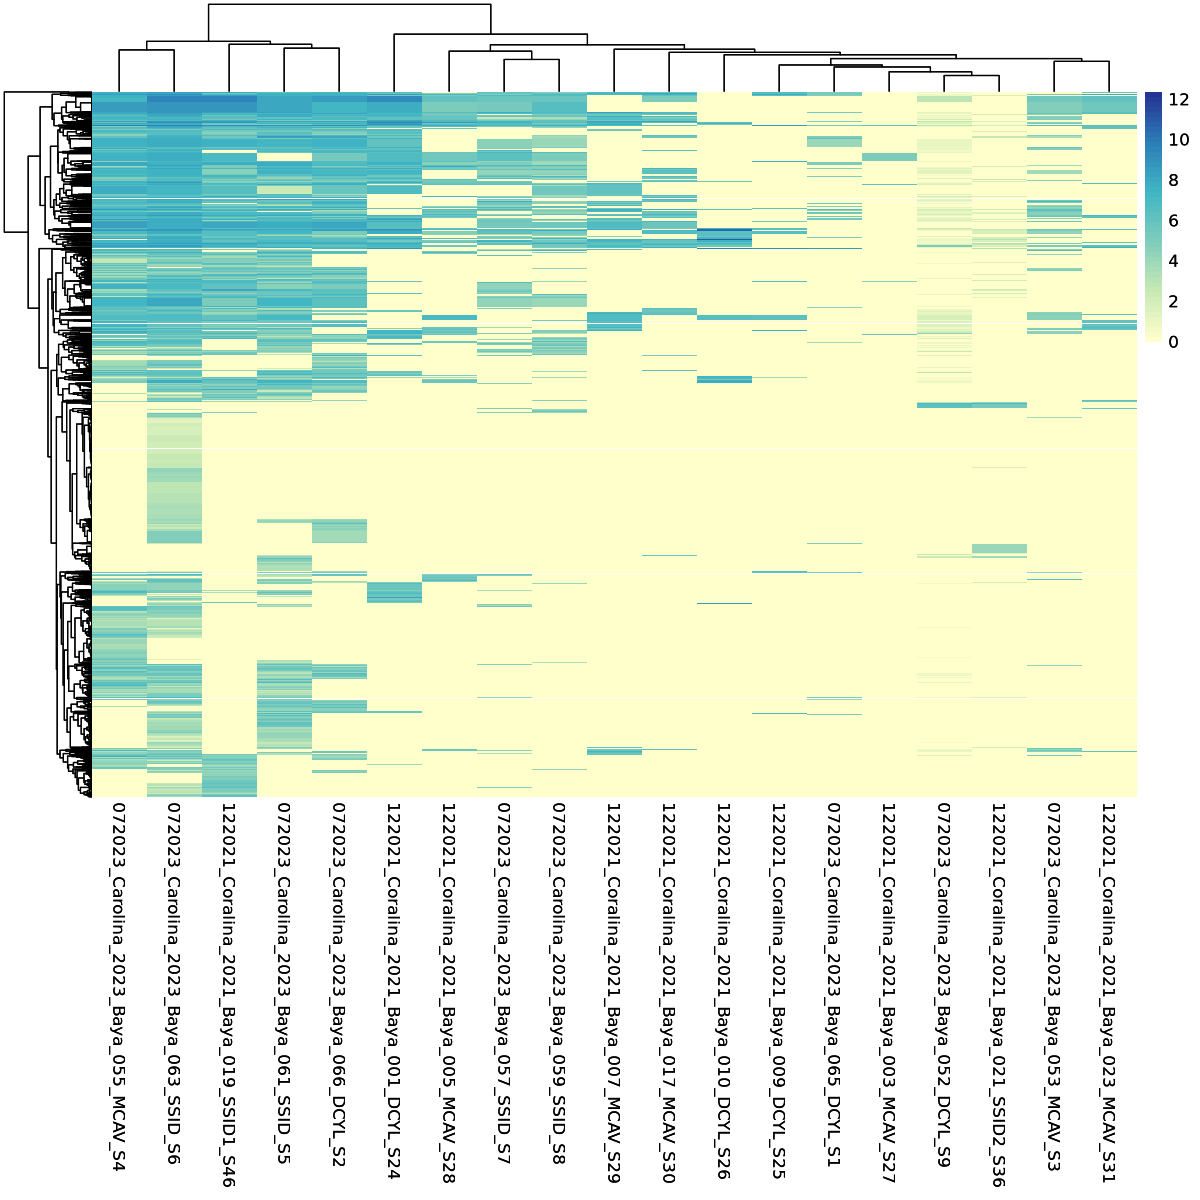

In [47]:
mcav_ssid_dcyl_genes_plot <- pheatmap(MCAV_SSID_DCYL_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         fontsize_col = 10,
         #legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         #legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
mcav_ssid_dcyl_genes_plot

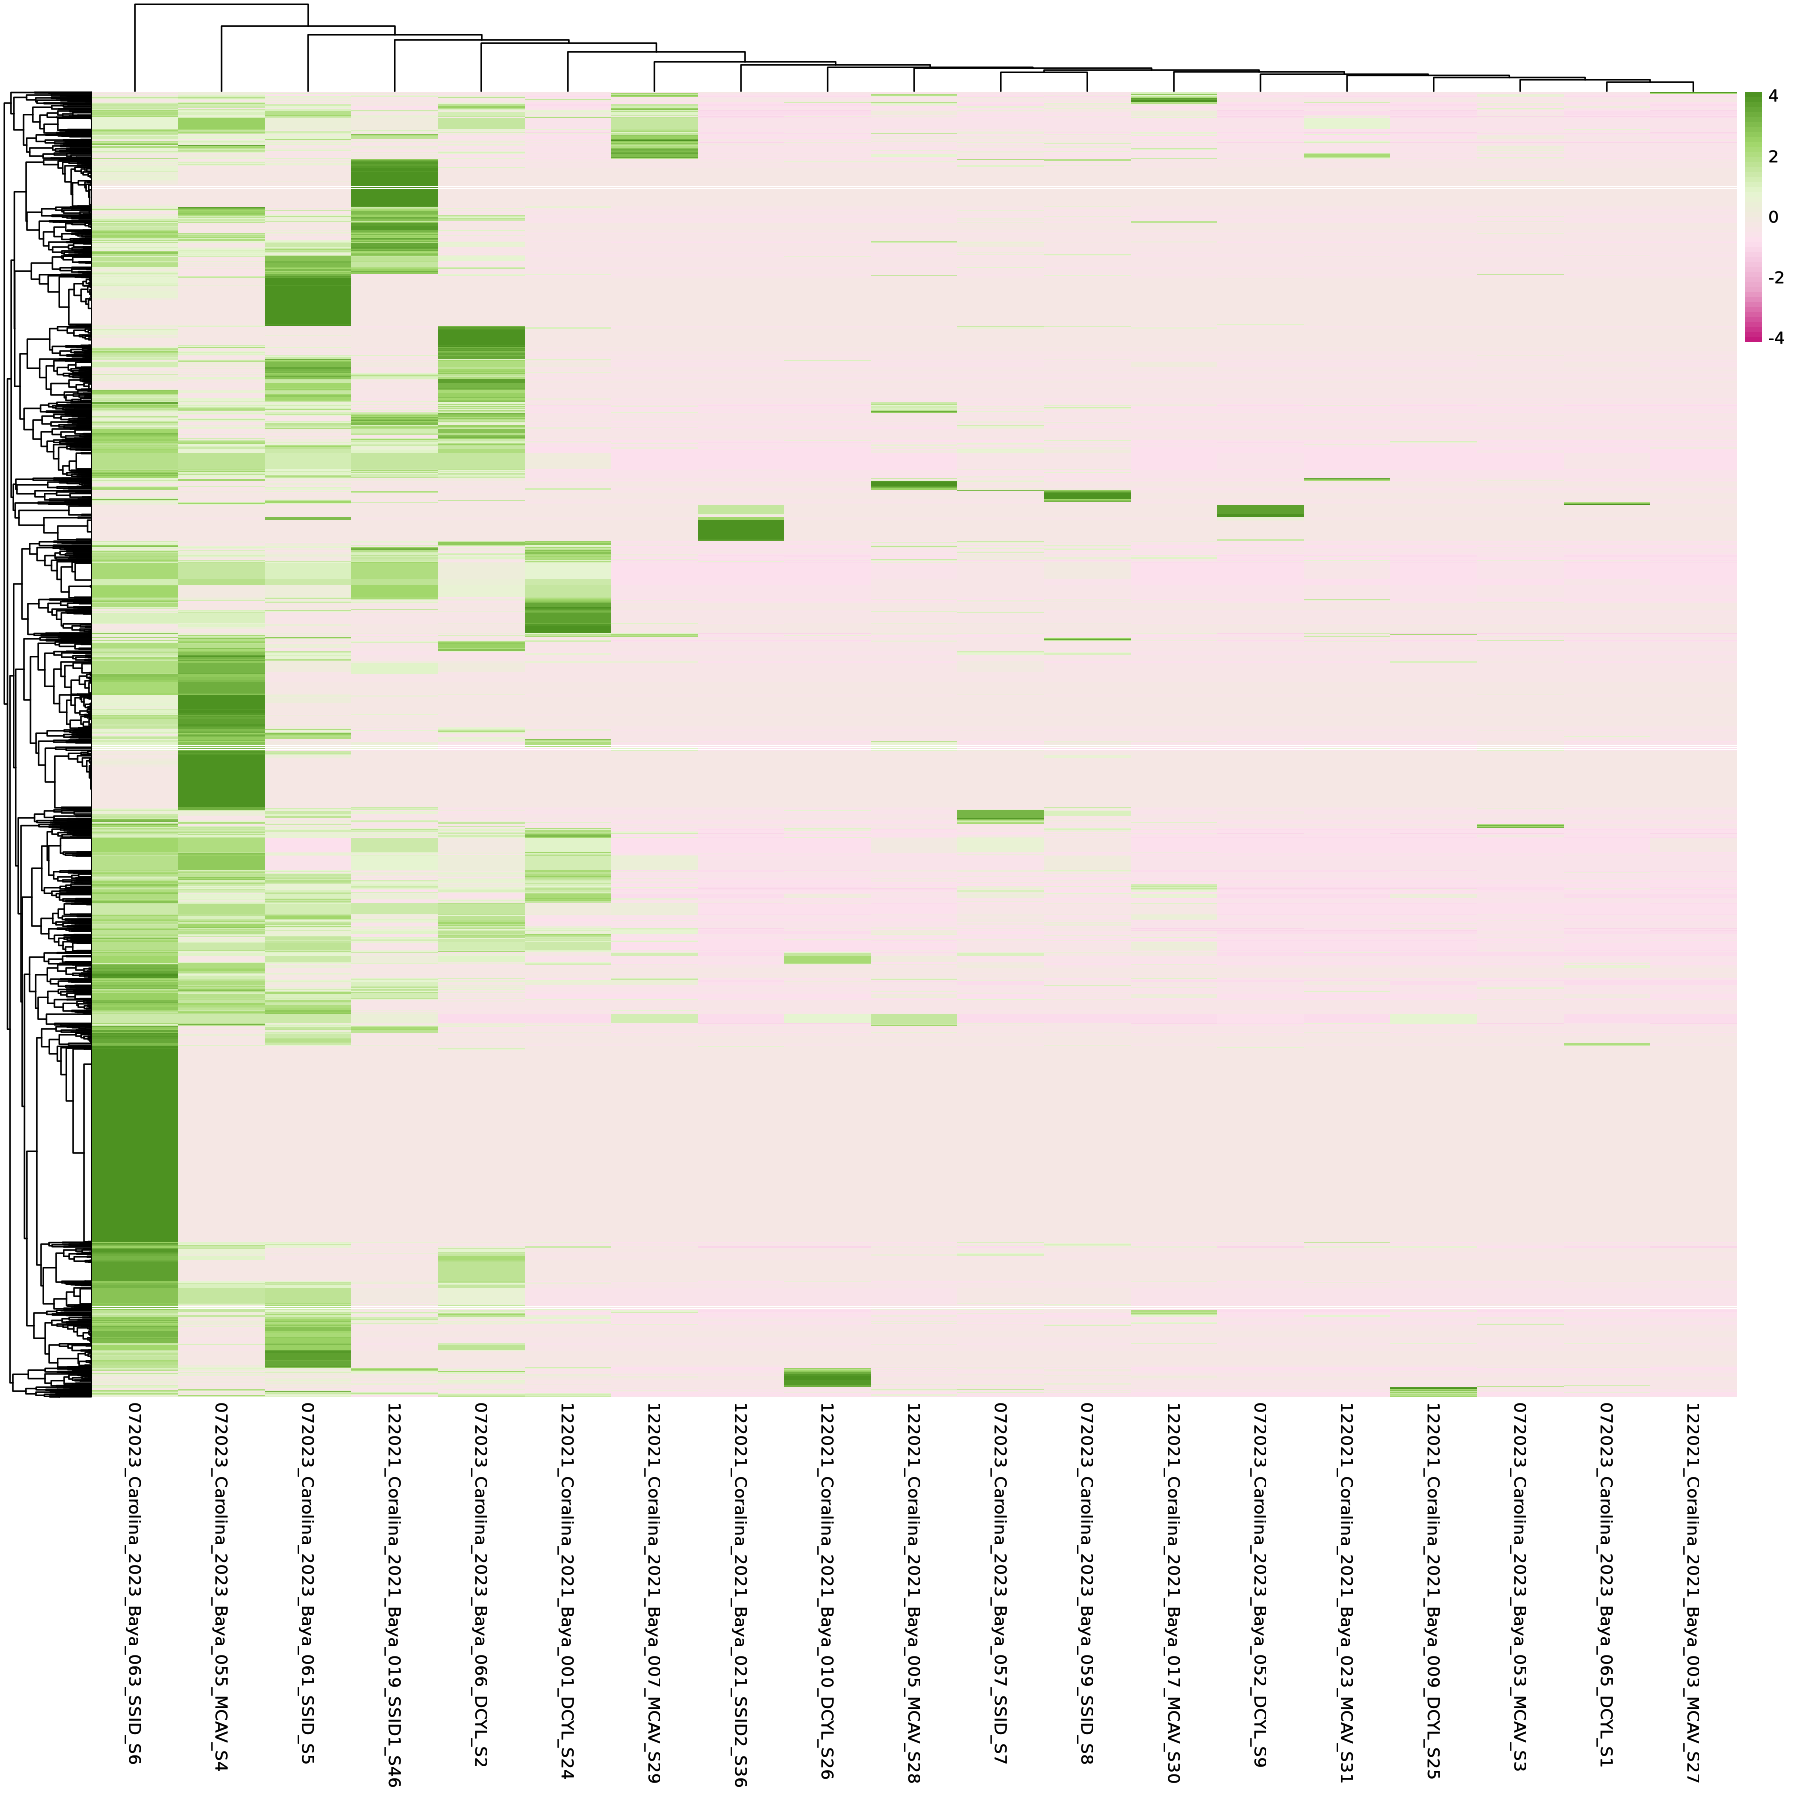

In [88]:
#try the scaling within heatmap
mcav_ssid_dcyl_genes_plot1 <- pheatmap(genes_filtered_MCAV_SSID_DCYL_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         #legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         #legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "row", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = my_colors)
mcav_ssid_dcyl_genes_plot1

## Do each species separately and see what pops out

### start with SSIDs

In [7]:
#remove specific rows in metadata
metadata_SSID <- metadata[!grepl("PSTR|DLAB|MMEA|MCAV|DCYL", metadata$SampleID), ]
dim(metadata_SSID)

[1] 6 6

In [4]:
genes_filtered_SSID <- read.csv("DR_SSID_genes_filtered.csv")
head(genes_filtered_SSID)

,Gene_Family,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X122021_Coralina_2021_Baya_019_SSID1_S46,X122021_Coralina_2021_Baya_021_SSID2_S36
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.0000,0,50.0707,65.57140,31.5559,0
2,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],21.5426,0,11.7578,52.04480,28.1884,0
3,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.0000,0,0.0000,16.22250,0.0000,0
4,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.0000,0,0.0000,5.36775,0.0000,0
5,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.0000,0,16.9971,0.00000,0.0000,0
6,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.0000,0,30.5974,10.66000,41.9772,0


In [5]:
#remove the first column and Xs in headers
names(genes_filtered_SSID) <- sub("^X", "", names(genes_filtered_SSID))

In [6]:
#index gene_family_row
row.names(genes_filtered_SSID) <- genes_filtered_SSID$Gene_Family
genes_filtered_SSID$Gene_Family <- NULL
#remove rows with zero sum
genes_filtered_SSID <- genes_filtered_SSID[rowSums(genes_filtered_SSID) != 0, ]
dim(genes_filtered_SSID)
head(genes_filtered_SSID)

[1] 3112    6

,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.0000,0,50.0707,65.57140,31.5559,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],21.5426,0,11.7578,52.04480,28.1884,0
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.0000,0,0.0000,16.22250,0.0000,0
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.0000,0,0.0000,5.36775,0.0000,0
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.0000,0,16.9971,0.00000,0.0000,0
1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.0000,0,30.5974,10.66000,41.9772,0


In [7]:
#make into matrix
genes_filtered_SSIDs=as.matrix(genes_filtered_SSID)

In [8]:
SSID_log_counts <- log2(genes_filtered_SSIDs + 1)

In [9]:
options(repr.plot.width=10, repr.plot.height=10)

In [54]:
#calculate z-score 
#mat_z_ssid <- t(scale(t(SSID_log_counts)))

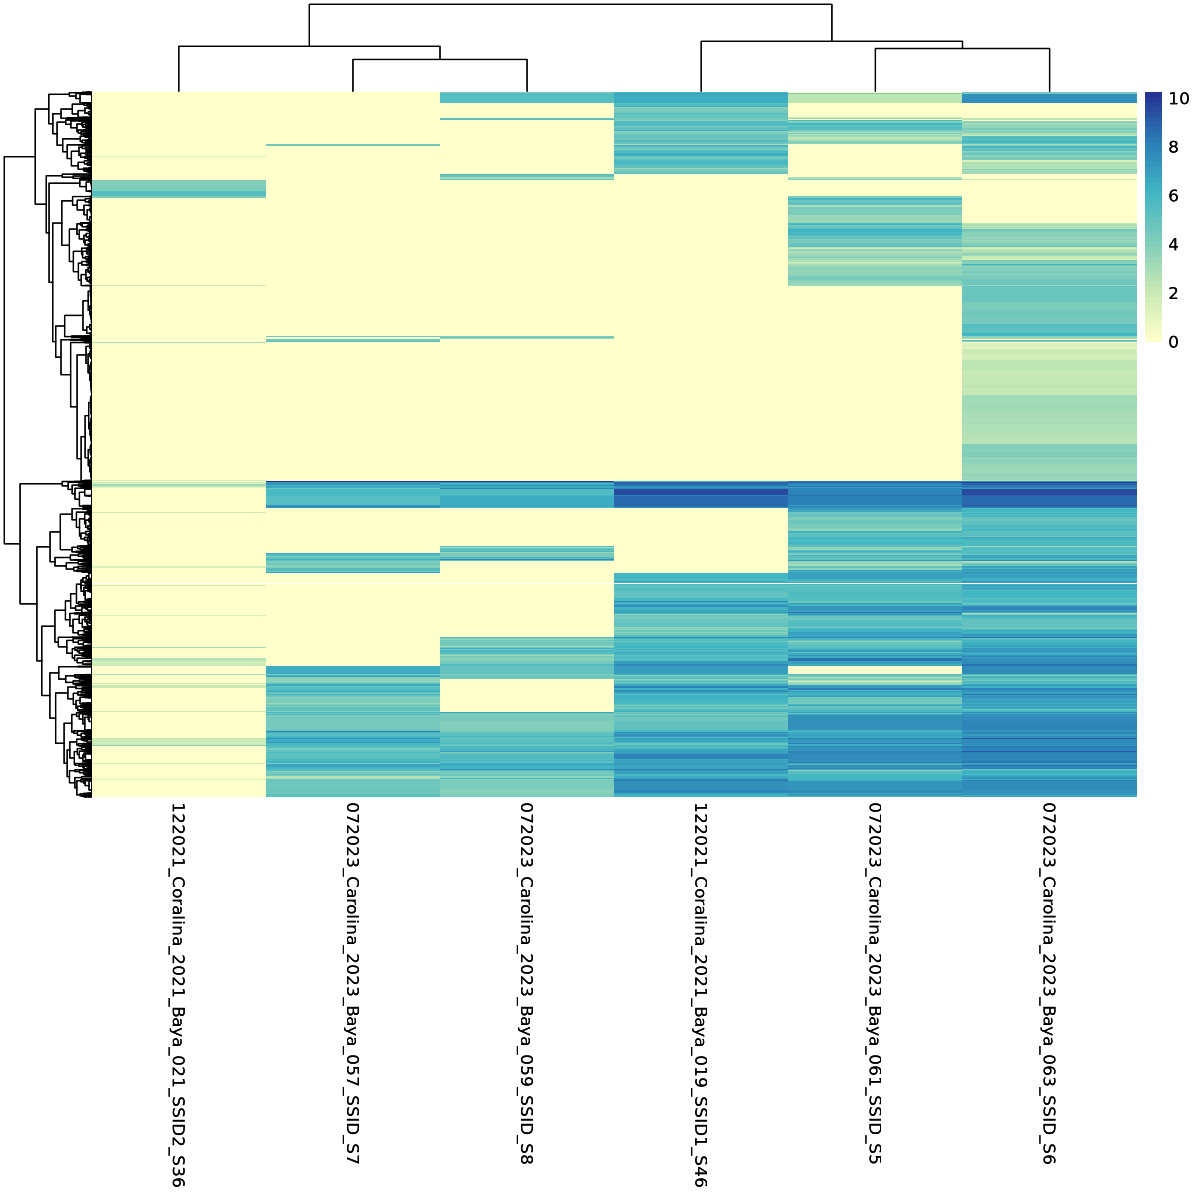

In [14]:
ssid_genes_plot <- pheatmap(SSID_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         fontsize_col = 10,
         #legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         #legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
ssid_genes_plot

In [56]:
ggsave(filename = "ssid_gene_log_heatmap.png", plot = ssid_genes_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [15]:
#Set up annotation information for heatmap
annotation_col <- data.frame(
  Colony = factor(c("SSID2", "SSID2", "SSID1", "SSID1", "SSID1", "SSID2")))
rownames(annotation_col) <- colnames(genes_filtered_SSID)

In [23]:
options(repr.plot.width=10, repr.plot.height=10)

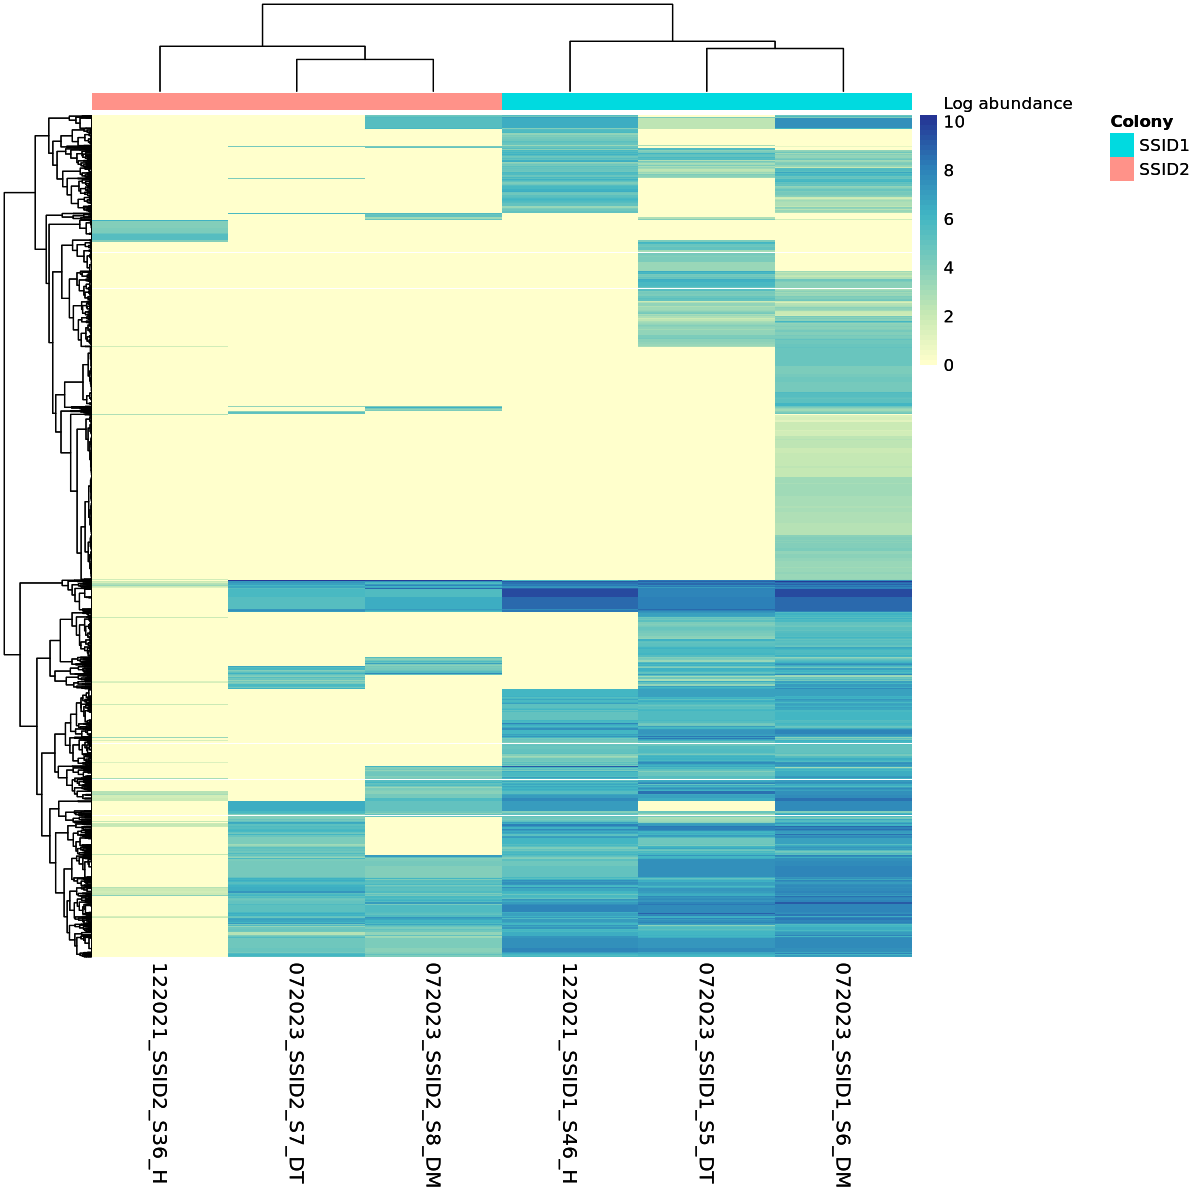

In [24]:
#make sample labels more informative and add annotation to columns
ssid_genes_plot1 <- pheatmap(SSID_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         fontsize_col = 12,
         legend_breaks = c(0, 2, 4, 6, 8, 10, max(SSID_log_counts)),
         legend_labels = c("0", "2", "4", "6", "8", "10", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors,
         annotation_names_col = FALSE,
         annotation_col = annotation_col,
         labels_col = c("072023_SSID2_S7_DT", "072023_SSID2_S8_DM", "072023_SSID1_S5_DT", 
                        "072023_SSID1_S6_DM", "122021_SSID1_S46_H","122021_SSID2_S36_H"))
ssid_genes_plot1

In [25]:
ggsave(filename = "ssid_gene_log_heatmap_labels.png", plot = ssid_genes_plot1, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

S46 is healthy, S5 is DT, S6 is DM of same colony. Not much of a pattern across sample types, except that DM and DT tissue seem to have slightly more gene families detected than healthy. Let's see if this holds for the other coral species

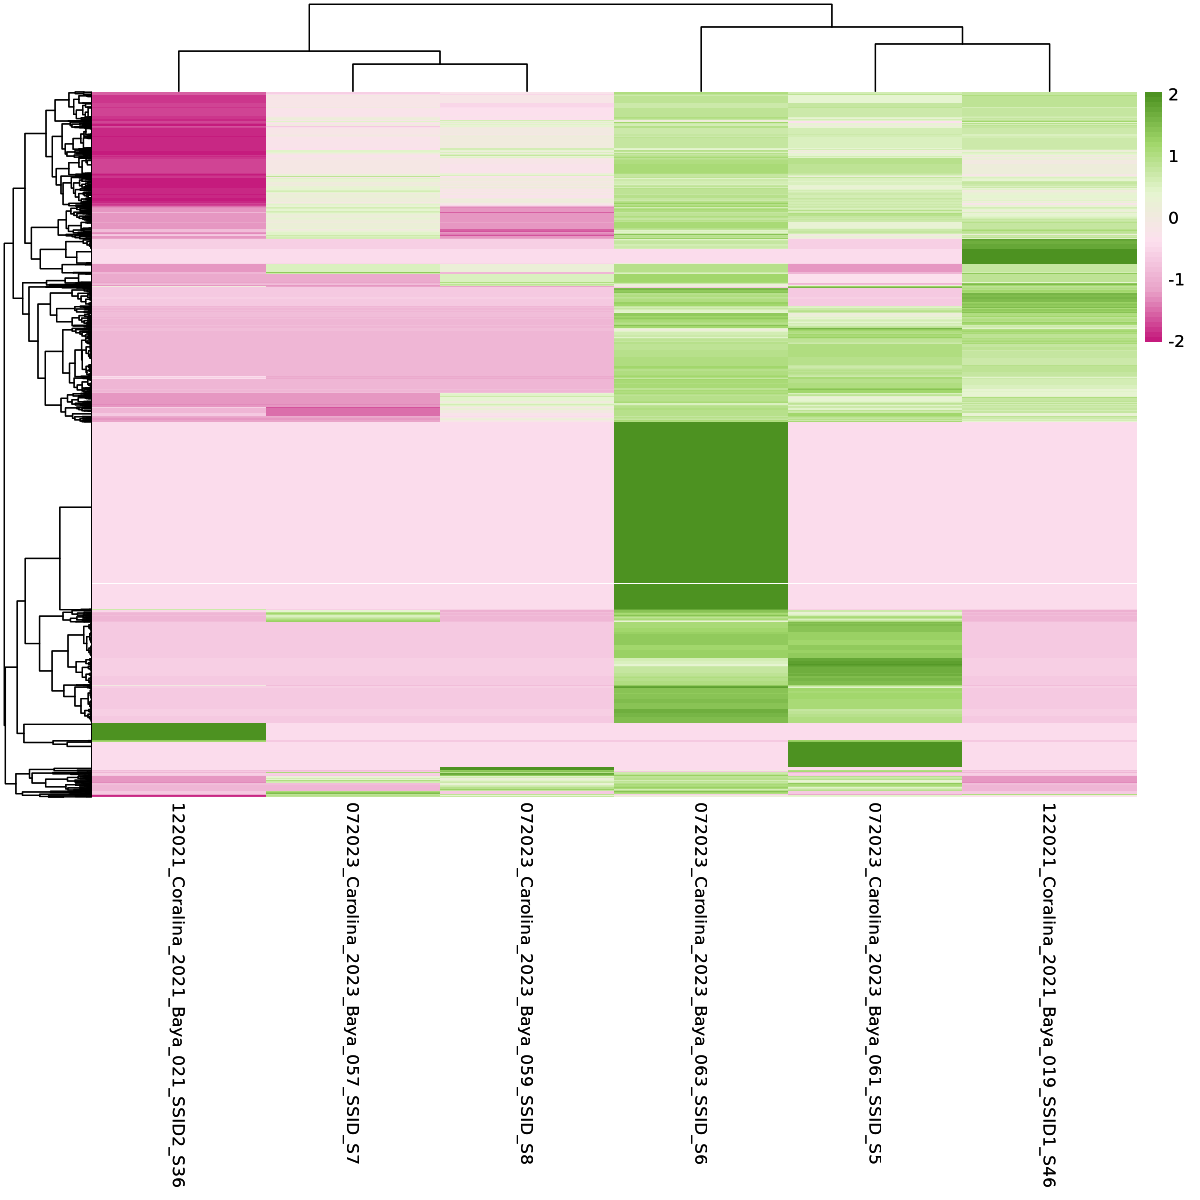

In [151]:
ssid_genes_plot1 <- pheatmap(mat_z_ssid, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         fontsize_col = 10,
         #legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         #legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = my_colors)
ssid_genes_plot1

In [152]:
ggsave(filename = "DR_ssid_functional_heatmap.png", plot = ssid_genes_plot1, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

looks like whether I scale within pheatmap or calculate z-score before, doesn't impact the results too much. Differences are slightly more pronounced with I calculate z-score on the matrix but I don't think these results make sense. Will do log norm abundances rather than scaling.

### MCAV

In [20]:
#remove specific rows in metadata
metadata_MCAV <- metadata[!grepl("PSTR|DLAB|MMEA|SSID|DCYL", metadata$SampleID), ]
dim(metadata_MCAV)

[1] 7 6

In [26]:
genes_filtered_MCAV <- read.csv("DR_MCAV_genes_filtered_clean.csv")
#removed S27 because low read ID
head(genes_filtered_MCAV)

,Gene_Family,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_023_MCAV_S31
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,146.0370,0,98.3238,0,61.9926
2,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,12.6499,0,0.0000,0,0.0000
3,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0,0.0000,0,0.0000
4,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.0000,0,0.0000,0,0.0000
5,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.0000,0,0.0000,0,0.0000
6,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0,0.0000,0,0.0000,0,0.0000


In [27]:
#remove Xs in headers
names(genes_filtered_MCAV) <- sub("^X", "", names(genes_filtered_MCAV))

In [28]:
#index gene_family_row
row.names(genes_filtered_MCAV) <- genes_filtered_MCAV$Gene_Family
genes_filtered_MCAV$Gene_Family <- NULL
#remove rows with zero sum
genes_filtered_MCAV <- genes_filtered_MCAV[rowSums(genes_filtered_MCAV) != 0, ]
dim(genes_filtered_MCAV)
head(genes_filtered_MCAV)

[1] 2000    6

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,146.03700,0,98.3238,0,61.9926
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,12.64990,0,0.0000,0,0.0000
1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,10.41560,0,0.0000,0,0.0000
1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],0,15.05060,0,0.0000,0,0.0000
1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],0,5.18922,0,24.3240,0,0.0000
1.1.1.39-RXN: (expasy) Malate dehydrogenase (oxaloacetate-decarboxylating) [1.1.1.38],0,17.42950,0,0.0000,0,0.0000


In [29]:
#make into matrix
genes_filtered_MCAVs=as.matrix(genes_filtered_MCAV)

In [30]:
MCAV_log_counts <- log2(genes_filtered_MCAVs + 1)

In [32]:
head(MCAV_log_counts)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,7.200035,0,6.634068,0,5.97711
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,3.770818,0,0.000000,0,0.00000
1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],0,3.512935,0,0.000000,0,0.00000
1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],0,4.004555,0,0.000000,0,0.00000
1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],0,2.629758,0,4.662433,0,0.00000
1.1.1.39-RXN: (expasy) Malate dehydrogenase (oxaloacetate-decarboxylating) [1.1.1.38],0,4.203945,0,0.000000,0,0.00000


In [62]:
#calculate z-score 
#mat_z_mcav <- t(scale(t(MCAV_log_counts)))

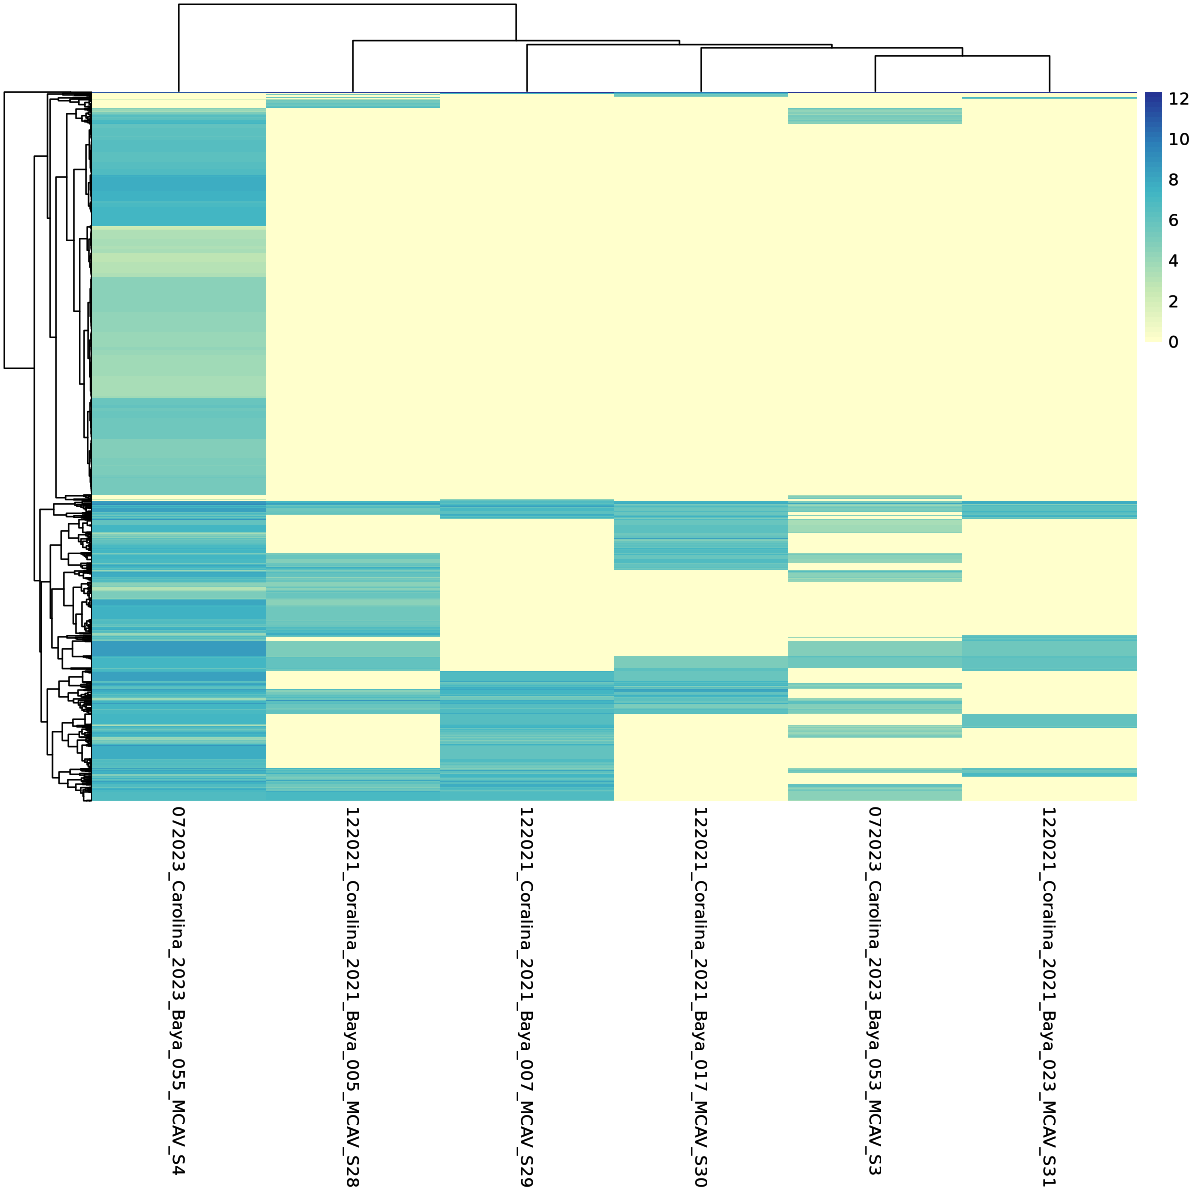

In [31]:
mcav_genes_plot <- pheatmap(MCAV_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         #legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         #legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
mcav_genes_plot

In [14]:
ggsave(filename = "mcav_gene_log_heatmap_clean.png", plot = mcav_genes_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

S4 is DM - S28 is H of the same colony, lots of gain in function in DM, whereas DT looks similar to healthy tissue

In [33]:
#Set up annotation information for heatmap (based on order in log counts matrix)
annotation_col <- data.frame(
  Colony = factor(c("MCAV3", "MCAV3", "MCAV3", "MCAV4", "MCAV9", "MCAV0")))
rownames(annotation_col) <- colnames(MCAV_log_counts)

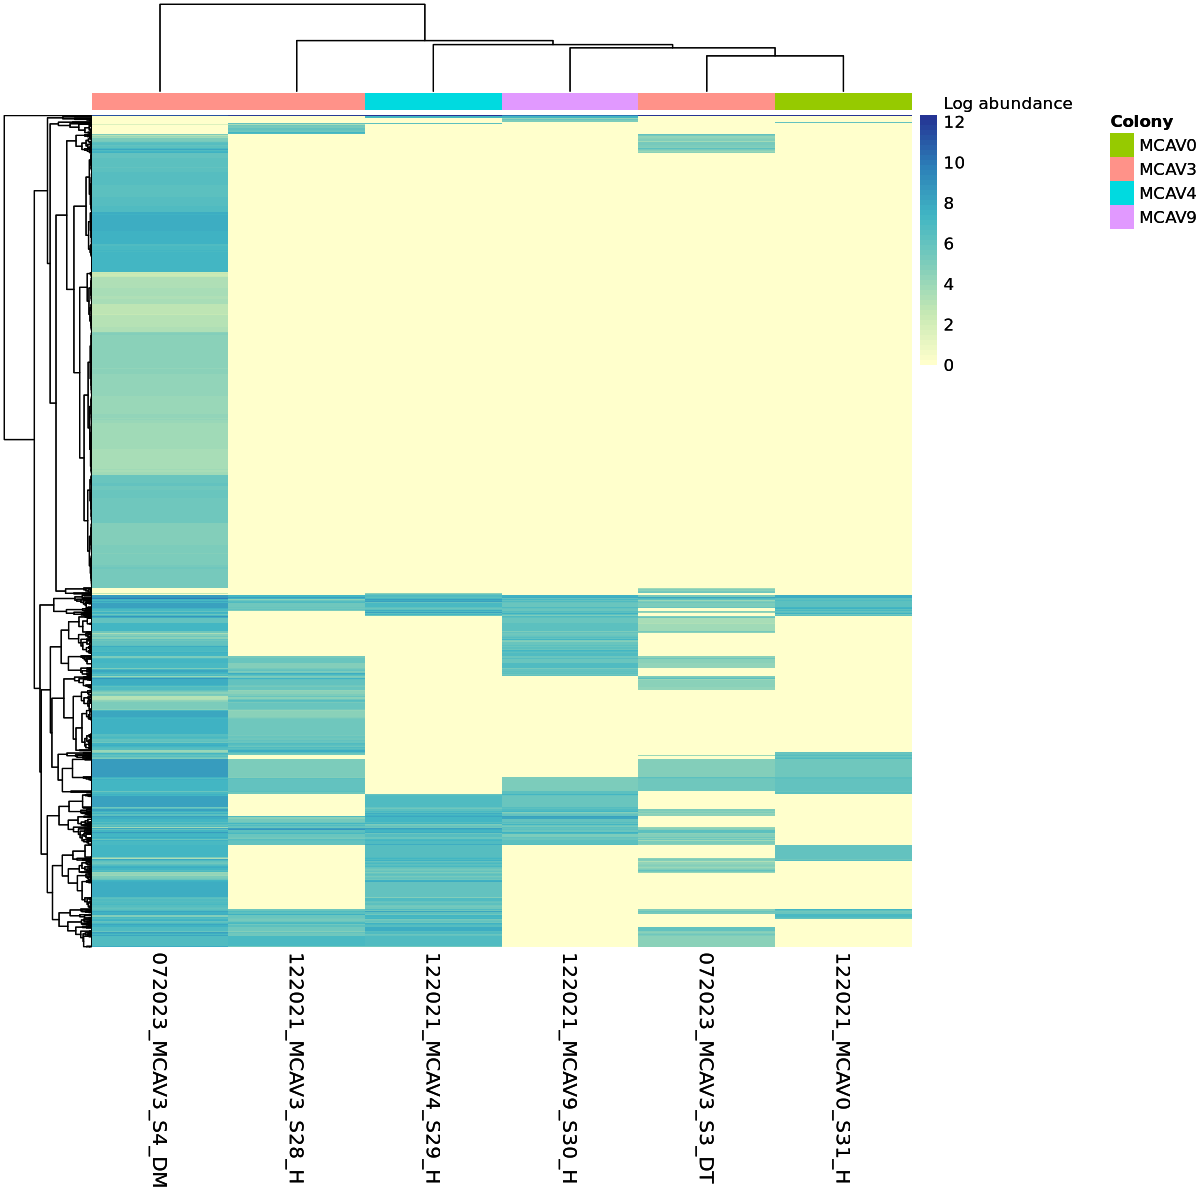

In [34]:
#make sample labels more informative and add annotation to columns
mcav_genes_plot1 <- pheatmap(MCAV_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         fontsize_col = 12,
         legend_breaks = c(0, 2, 4, 6, 8, 10, 12, max(MCAV_log_counts)),
         legend_labels = c("0", "2", "4", "6", "8", "10", "12", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors,
         annotation_names_col = FALSE,
         annotation_col = annotation_col,
         labels_col = c("072023_MCAV3_S3_DT", "072023_MCAV3_S4_DM", "122021_MCAV3_S28_H", "122021_MCAV4_S29_H",
                        "122021_MCAV9_S30_H","122021_MCAV0_S31_H"))
mcav_genes_plot1

In [35]:
ggsave(filename = "mcav_gene_log_heatmap_clean_labels.png", plot = mcav_genes_plot1, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### DCYL

In [29]:
#remove specific rows in metadata
metadata_DCYL <- metadata[!grepl("PSTR|DLAB|MMEA|SSID|MCAV", metadata$SampleID), ]
dim(metadata_DCYL)

[1] 6 6

In [36]:
genes_filtered_DCYL <- read.csv("DR_DCYL_genes_filtered.csv")
head(genes_filtered_DCYL)

,Gene_Family,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_065_DCYL_S1,X072023_Carolina_2023_Baya_066_DCYL_S2,X122021_Coralina_2021_Baya_001_DCYL_S24,X122021_Coralina_2021_Baya_009_DCYL_S25,X122021_Coralina_2021_Baya_010_DCYL_S26
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.84192,0,100.5450,0.0000,0,0
2,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,33.9994,51.8936,0,0
3,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0,0.0000,0.0000,0,0
4,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0,0.0000,0.0000,0,0
5,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.00000,0,0.0000,0.0000,0,0
6,1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.00000,0,0.0000,0.0000,0,0


In [37]:
#remove Xs in headers
names(genes_filtered_DCYL) <- sub("^X", "", names(genes_filtered_DCYL))

In [38]:
#index gene_family_row
row.names(genes_filtered_DCYL) <- genes_filtered_DCYL$Gene_Family
genes_filtered_DCYL$Gene_Family <- NULL
#remove rows with zero sum
genes_filtered_DCYL <- genes_filtered_DCYL[rowSums(genes_filtered_DCYL) != 0, ]
dim(genes_filtered_DCYL)
head(genes_filtered_DCYL)

[1] 1826    6

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,122021_Coralina_2021_Baya_009_DCYL_S25,122021_Coralina_2021_Baya_010_DCYL_S26
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.841920,0,100.5450,0.0000,0,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.000000,0,33.9994,51.8936,0,0
1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],0.000000,0,0.0000,64.5961,0,0
1.1.1.291-RXN: (expasy) 2-hydroxymethylglutarate dehydrogenase [1.1.1.291],0.237833,0,0.0000,0.0000,0,0
1.1.1.83-RXN: (expasy) D-malate dehydrogenase (decarboxylating) [1.1.1.83],0.832591,0,75.2973,0.0000,0,0
1.14.11.1-RXN: (expasy) Gamma-butyrobetaine dioxygenase [1.14.11.1],0.675827,0,0.0000,0.0000,0,0


In [39]:
#make into matrix
genes_filtered_DCYLs=as.matrix(genes_filtered_DCYL)

In [40]:
DCYL_log_counts <- log2(genes_filtered_DCYLs + 1)

In [70]:
#calculate z-score 
#mat_z_dcyl <- t(scale(t(DCYL_log_counts)))

In [138]:
options(repr.plot.width=10, repr.plot.height=10)

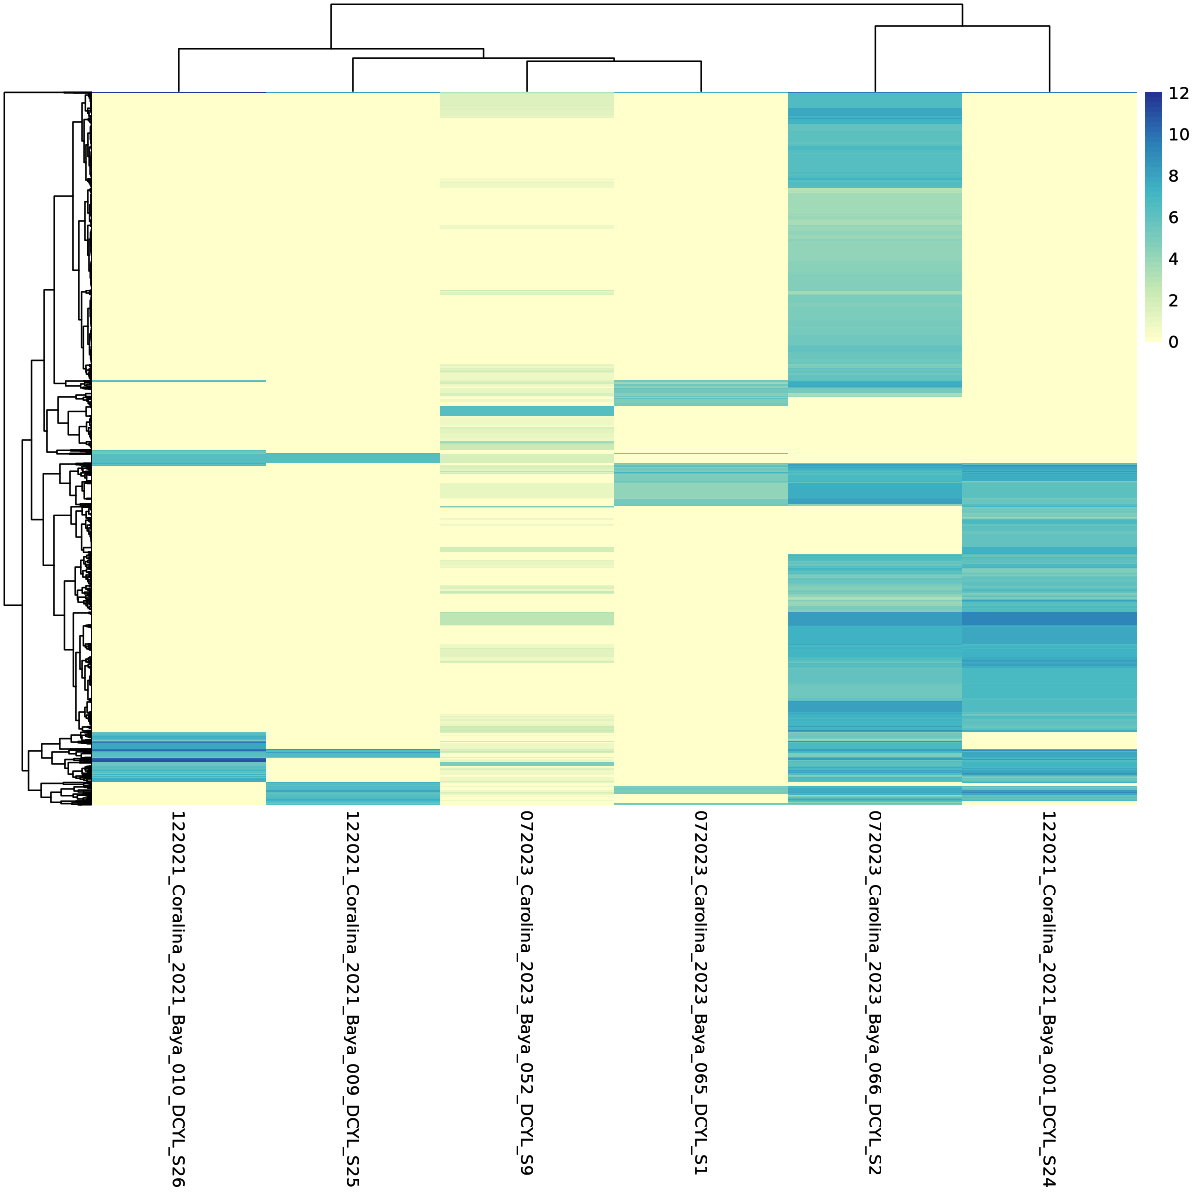

In [41]:
dcyl_genes_plot <- pheatmap(DCYL_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         #legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         #legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
dcyl_genes_plot

In [72]:
ggsave(filename = "dcyl_gene_log_heatmap.png", plot = dcyl_genes_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

009 is healthy and 052 is DM of same colony DCYL5 \
010 is healthy and it died \
001 is healthy and 066 is DM, 065 is DT of same colony (i think) DCYL1

In [42]:
#Set up annotation information for heatmap (based on order in log counts matrix)
annotation_col <- data.frame(
  Colony = factor(c("DCYL5", "DCYL1", "DCYL1", "DCYL1", "DCYL5", "DCYL6")))
rownames(annotation_col) <- colnames(DCYL_log_counts)

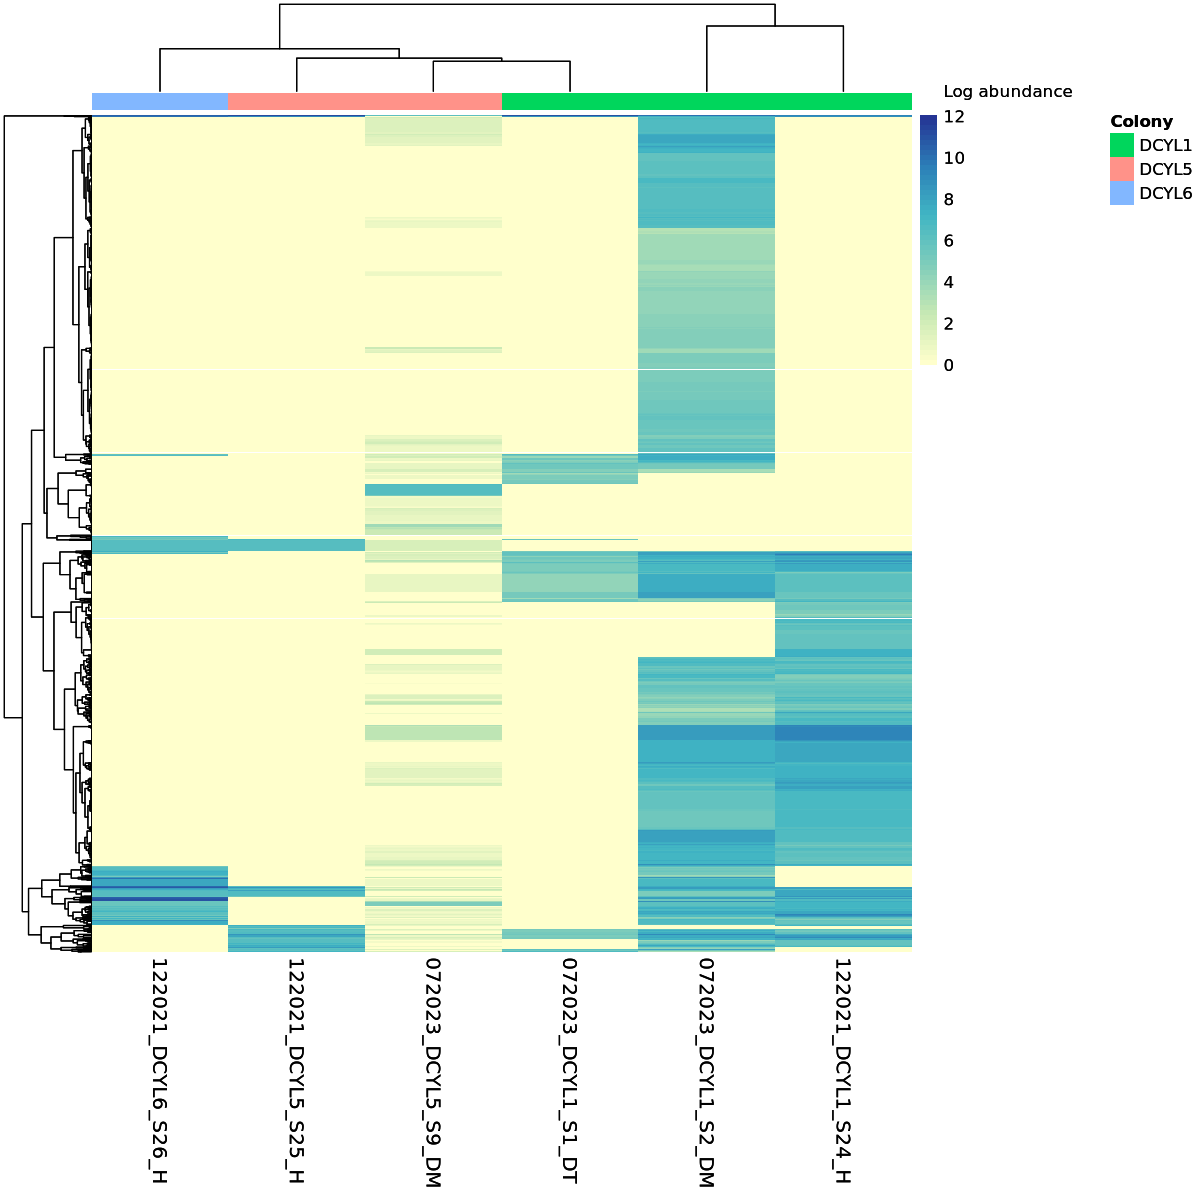

In [46]:
#make sample labels more informative and add annotation to columns
dcyl_genes_plot1 <- pheatmap(DCYL_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         fontsize_col = 12,
         legend_breaks = c(0, 2, 4, 6, 8, 10, 12, max(DCYL_log_counts)),
         legend_labels = c("0", "2", "4", "6", "8", "10", "12", "Log abundance\n\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors,
         annotation_names_col = FALSE,
         annotation_col = annotation_col,
         labels_col = c("072023_DCYL5_S9_DM", "072023_DCYL1_S1_DT", "072023_DCYL1_S2_DM", 
                        "122021_DCYL1_S24_H", "122021_DCYL5_S25_H","122021_DCYL6_S26_H"))
dcyl_genes_plot1

In [47]:
ggsave(filename = "dcyl_gene_log_heatmap_labels.png", plot = dcyl_genes_plot1, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

### Number of reads vs detected gene families

In [18]:
install.packages("patchwork")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [19]:
library(patchwork)

In [3]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken/symbionts")

In [41]:
symb_reads <- read.csv("DR_reads_genes.csv")

In [42]:
head(symb_reads)

,Sample_ID,Reads,Gene_families,Sample
,<chr>,<int>,<int>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,119041,4722,072023_MCAV3_S3_DT
2,072023_Carolina_2023_Baya_055_MCAV_S4,275961,29322,072023_MCAV3_S4_DM
3,122021_Coralina_2021_Baya_005_MCAV_S28,46677,5240,122021_MCAV3_S28_H
4,122021_Coralina_2021_Baya_007_MCAV_S29,115215,3952,122021_MCAV4_S29_H
5,122021_Coralina_2021_Baya_017_MCAV_S30,31184,3901,122021_MCAV9_S30_H
6,122021_Coralina_2021_Baya_023_MCAV_S31,75058,2197,122021_MCAV0_S31_H


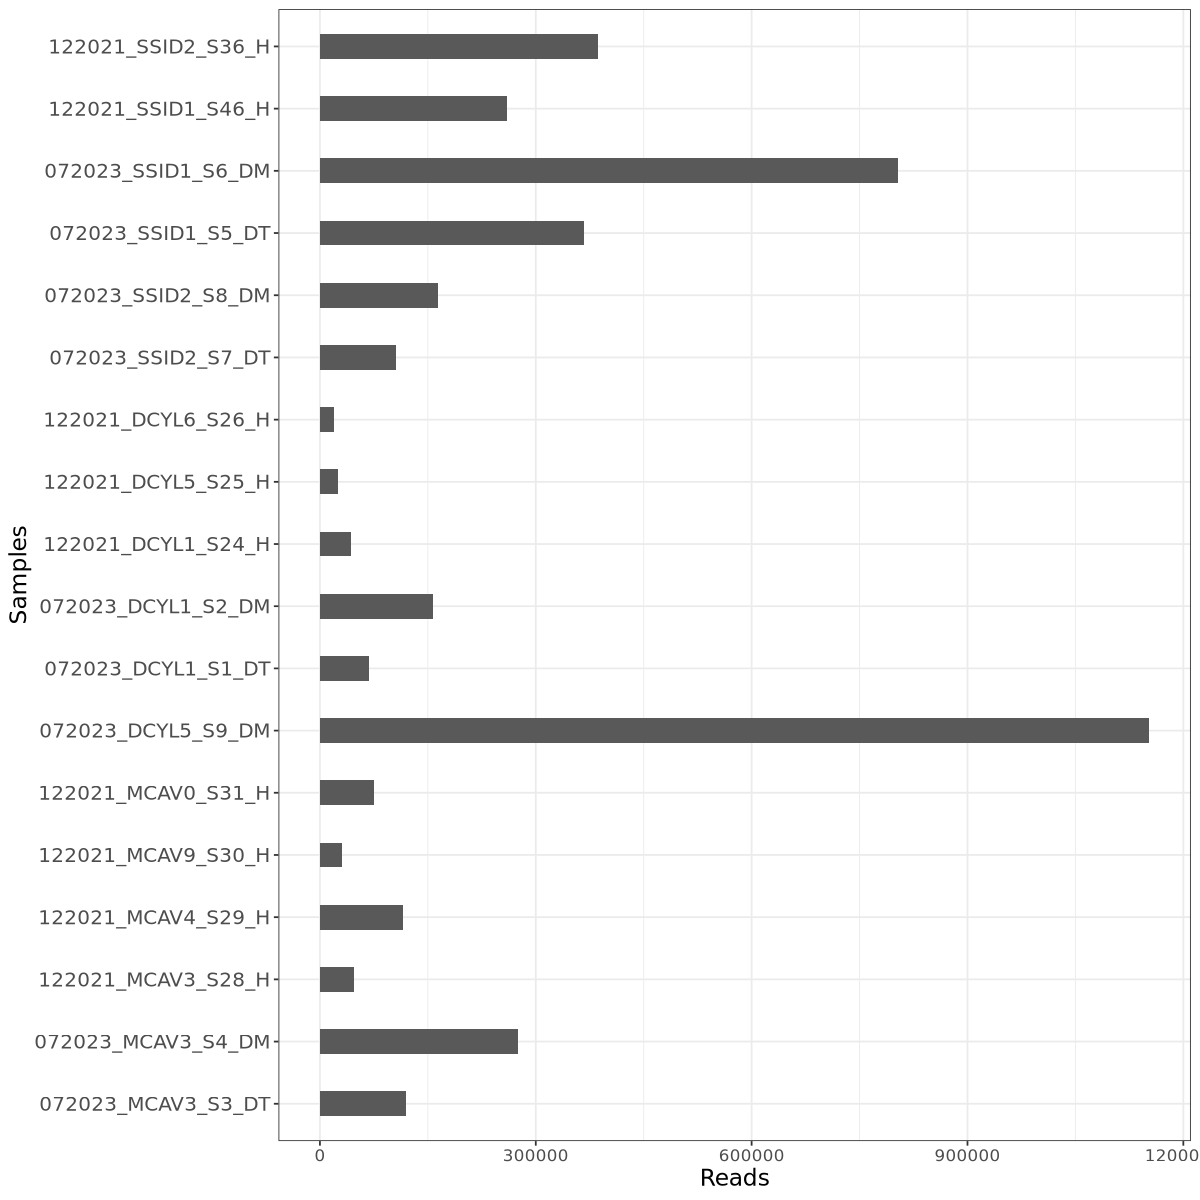

In [43]:
reads_plot <- ggplot(symb_reads, aes(x=fct_inorder(Sample), y=Reads)) +
               geom_bar(stat = "identity", width = 0.4) +
               coord_flip() + # Rotates the bars horizontally
             theme_bw() +
             theme(axis.text.x = element_text(size = 10),
                   axis.text.y = element_text(size = 12),
                   axis.title.x = element_text(size = 14),
                  axis.title.y = element_text(size = 14))+
             labs(x = "Samples")
reads_plot
               

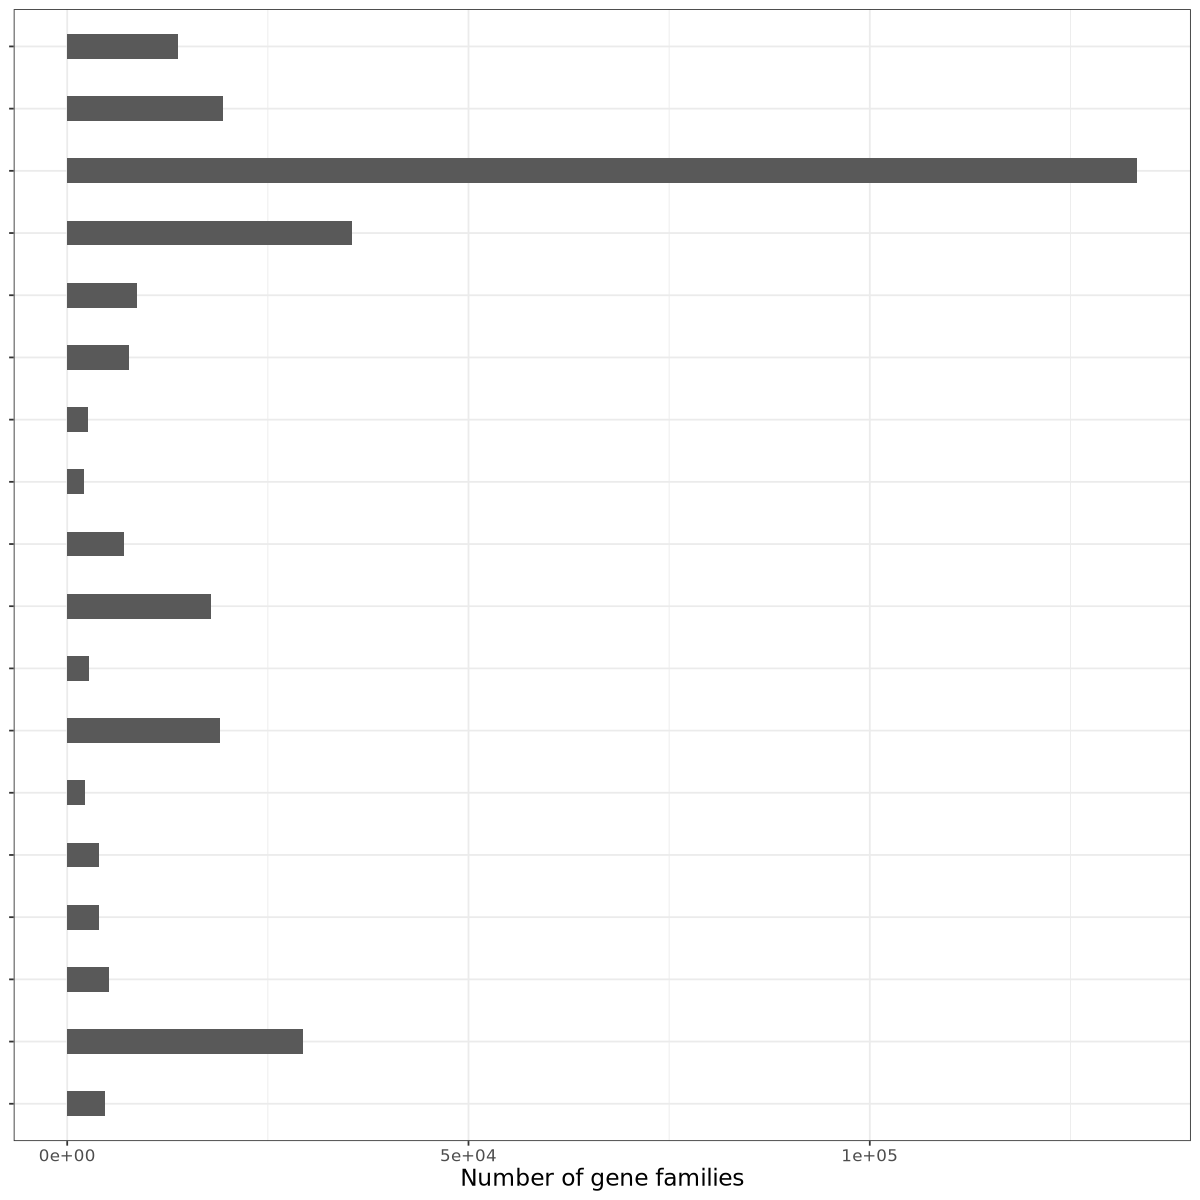

In [44]:
genes_plot <- ggplot(symb_reads, aes(x=fct_inorder(Sample), y=Gene_families)) +
               geom_bar(stat = "identity", width = 0.4) +
               coord_flip() + # Rotates the bars horizontally
            theme_bw() +
            theme(axis.text.y = element_blank(),
                 axis.title.y = element_blank(),
                 axis.text.x = element_text(size = 10),
                 axis.title.x = element_text(size = 14)) + 
            labs(y = "Number of gene families")
genes_plot

In [26]:
options(repr.plot.width=10, repr.plot.height=10)

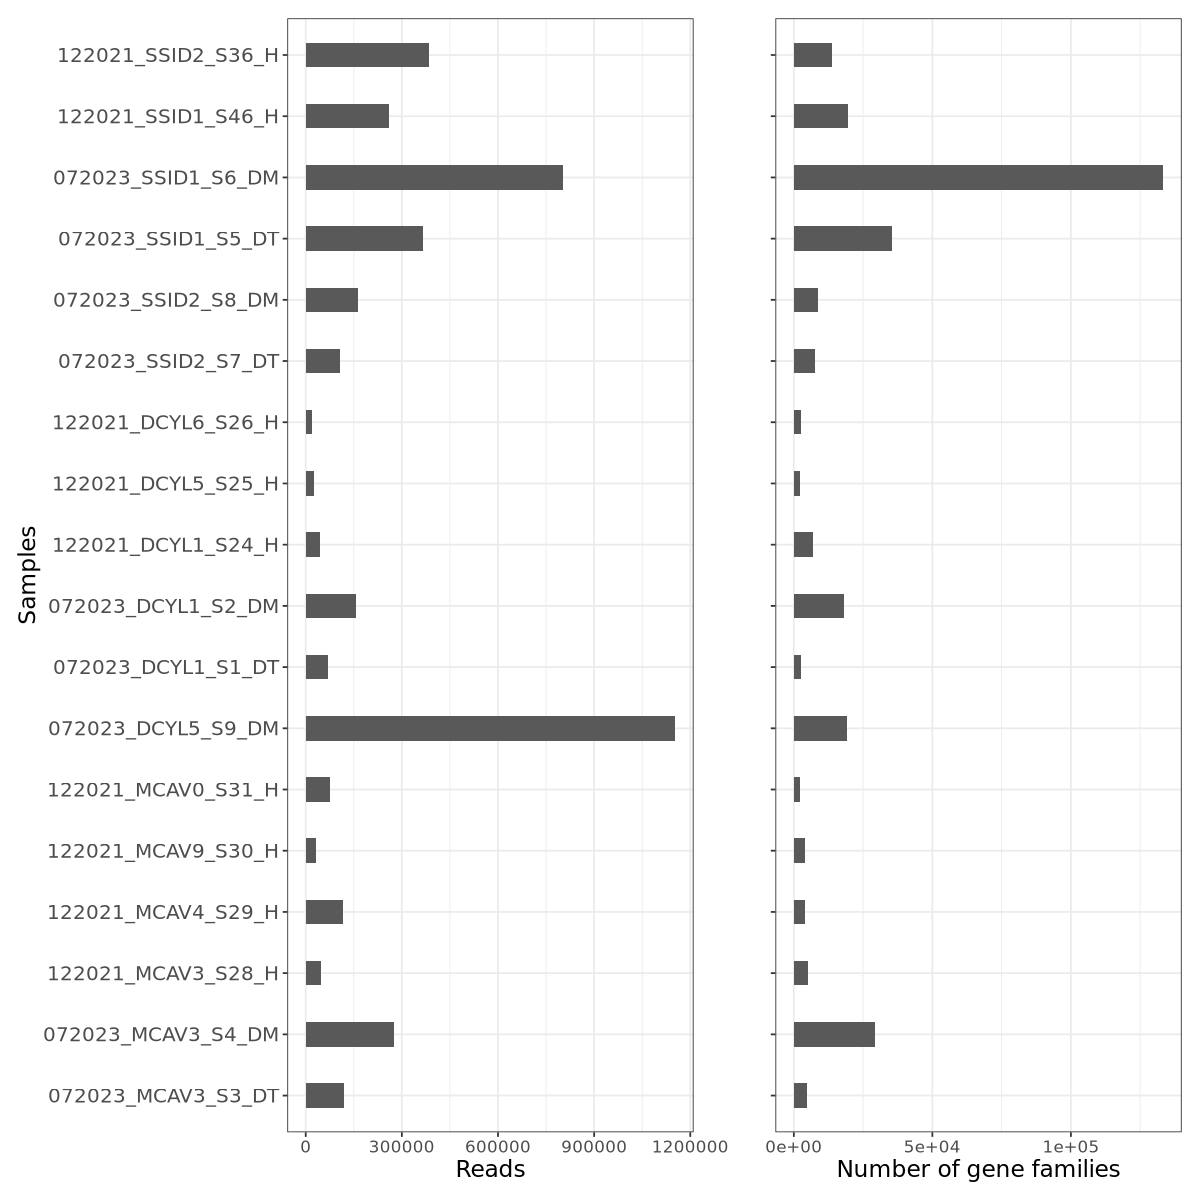

In [48]:
combined_plot <- reads_plot + plot_spacer() + genes_plot + plot_layout(widths = c(1, 0.1, 1))
combined_plot

In [49]:
ggsave(filename = "Reads_vs_gene_families_barplot.png", plot = combined_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)